In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, normaltest
import warnings
import os 


warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print(os.getcwd())
# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)


# Loading of the processed data files

# df = pd.read_parquet('processed_data_test_100.parquet')
df = pd.read_parquet('processed_data_tickers_100_with_additional_filtered_out.parquet')
df = df[df['Date'] < '2025-09-15']

/home/yinkiat/fyp-kiat/ML_Core/data/processed_data


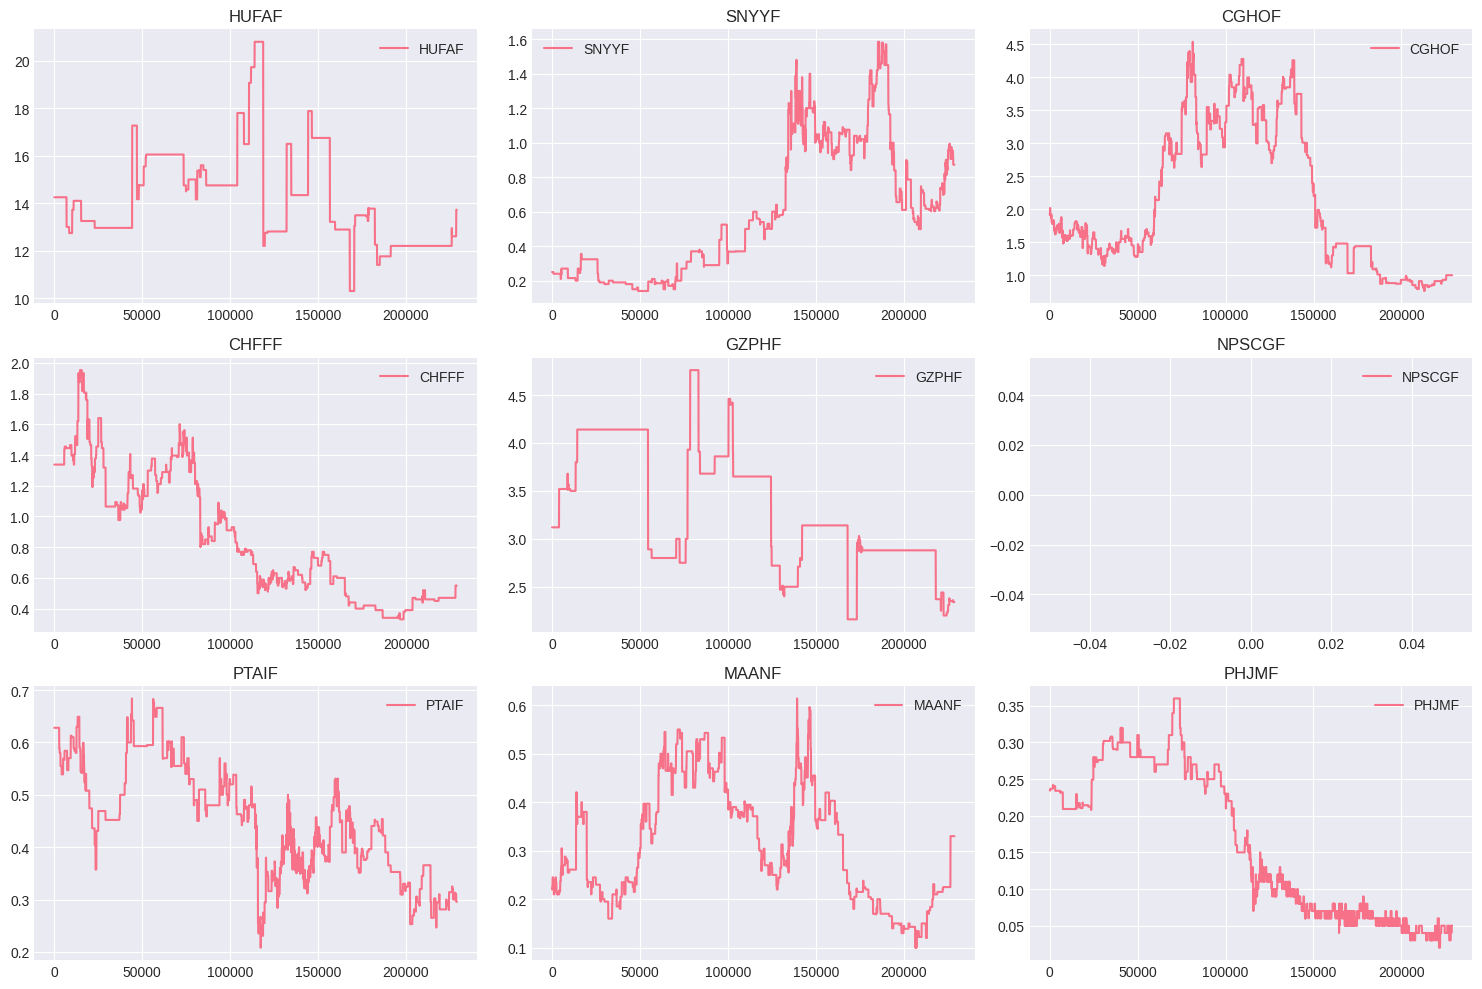

In [8]:
import matplotlib.pyplot as plt

tickers = ['HUFAF', 'SNYYF', 'CGHOF', 'CHFFF', 'GZPHF', 'NPSCGF', 'PTAIF', 'MAANF', 'PHJMF']

# Determine grid size (e.g., 3x3 for 9 tickers)
n = len(tickers)
rows = int(n**0.5)
cols = -(-n // rows)  # Ceiling division

fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
axes = axes.flatten()  # Flatten to 1D array for easy iteration

for i, ticker in enumerate(tickers):
    ax = axes[i]
    sub_df = df[df['Ticker'] == ticker]
    ax.plot(sub_df['Close'], label=ticker)
    ax.set_title(ticker)
    ax.legend()
    ax.grid(True)

# Hide unused subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Investigating the Volatility of all the Close Prices for each ticker ###

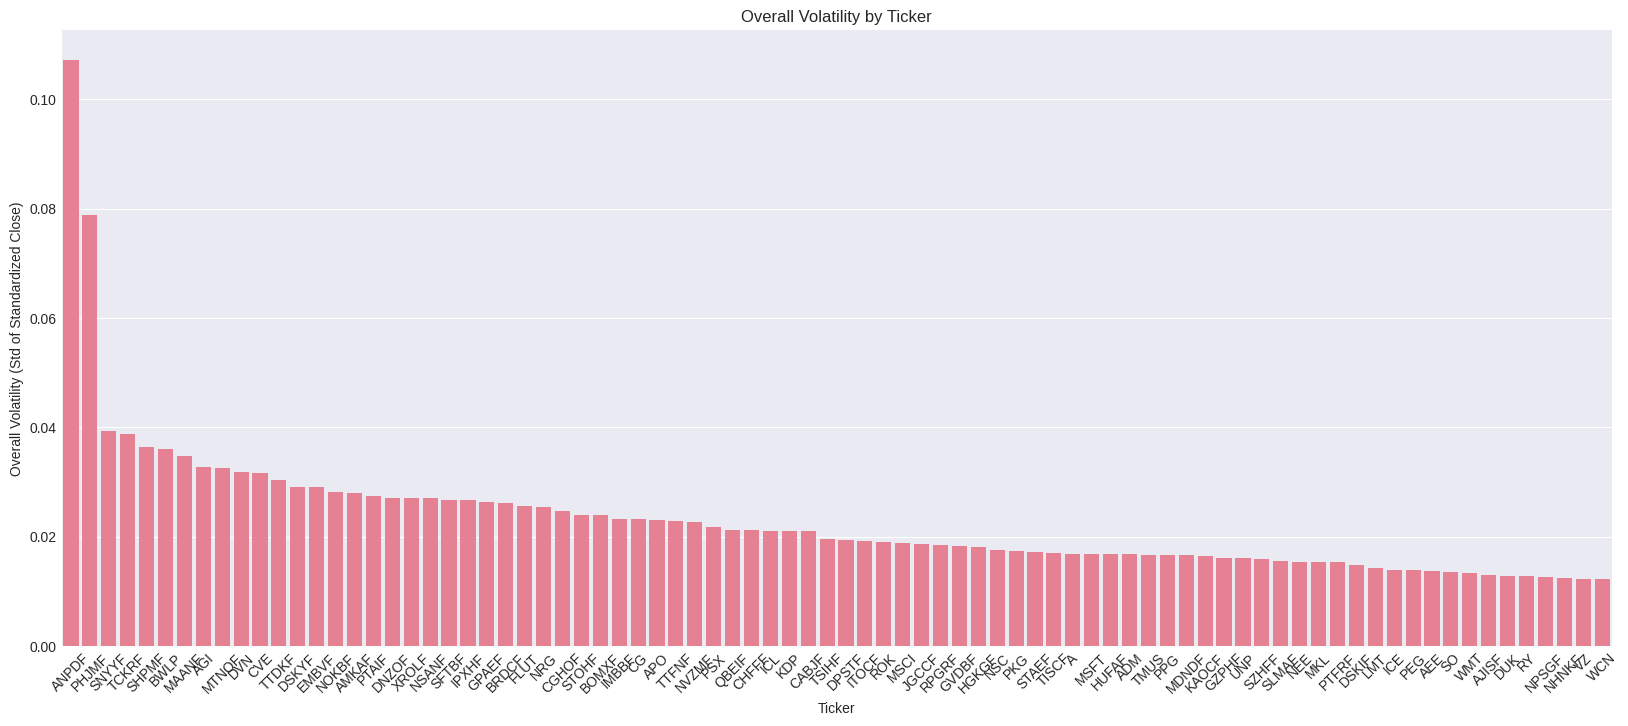

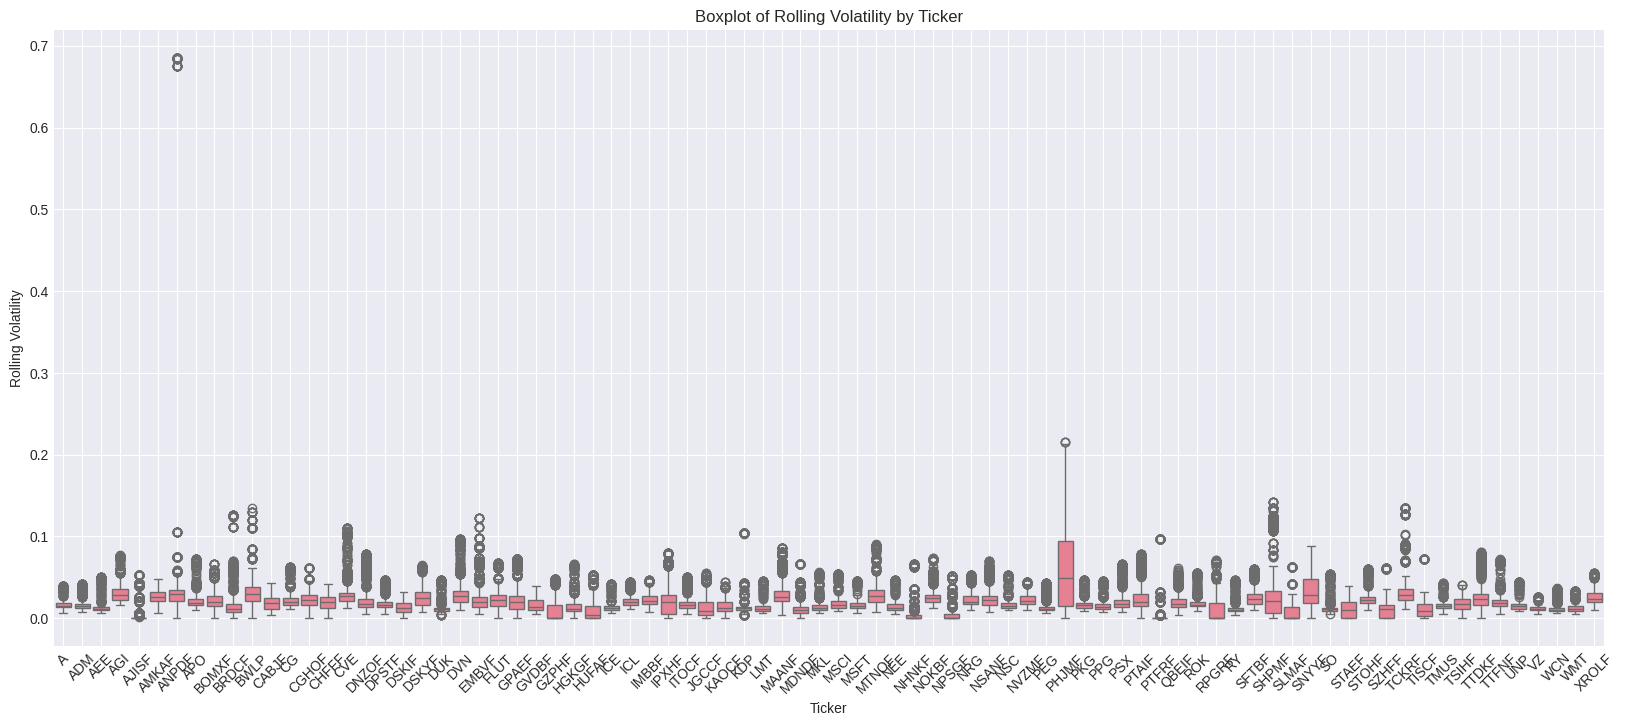

In [ ]:
df_vol = df[['Date', 'Ticker', 'Close']].copy()

tickers_to_drop = ['MTRJF', 'PBMRF', 'BLBRF', 'ACPIF', 'PIKQF', 'UBEOF', 'AITUF', 'AVIJF', 'MNTHF', 'SBSNF', 'TSUSF', 'JPTXF', 'AYAAF', 'AKBLF', 'PORBF', 'COLZF', 'YTLCF', 'OLCLF']
df_vol = df_vol[~df_vol['Ticker'].isin(tickers_to_drop)]

# Normalize all prices by Ticker
df_vol['Standardized_Close'] = df_vol.groupby('Ticker')['Close'].transform(
    lambda x: (x - x.mean()) / x.std()
)

df_vol['Returns'] = df_vol.groupby('Ticker')['Close'].pct_change() 

# Calculate Overall Volatility Group by Tick
volatility_df = df_vol.groupby('Ticker')['Returns'].std().reset_index()

# Make rolling Window of 63 days then calculate rolling volatility
df_vol['Rolling_Volatility'] = df_vol.groupby('Ticker')['Returns'].transform(
    lambda x: x.rolling(window=63).std()
)


# Plot sorted barplot for the volaility df by Ticker
plt.figure(figsize=(20, 8))
volatility_df = volatility_df.sort_values(by='Returns', ascending=False)
sns.barplot(x='Ticker', y='Returns', data=volatility_df)
plt.title('Overall Volatility by Ticker')
plt.xlabel('Ticker')
plt.ylabel('Overall Volatility (Std of Standardized Close)')
plt.xticks(rotation=45)
plt.show()



# Plot Boxplot for the rolling volatility
plt.figure(figsize=(20, 8))
sns.boxplot(x='Ticker', y='Rolling_Volatility', data=df_vol)
plt.title('Boxplot of Rolling Volatility by Ticker')
plt.xlabel('Ticker')
plt.ylabel('Rolling Volatility')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


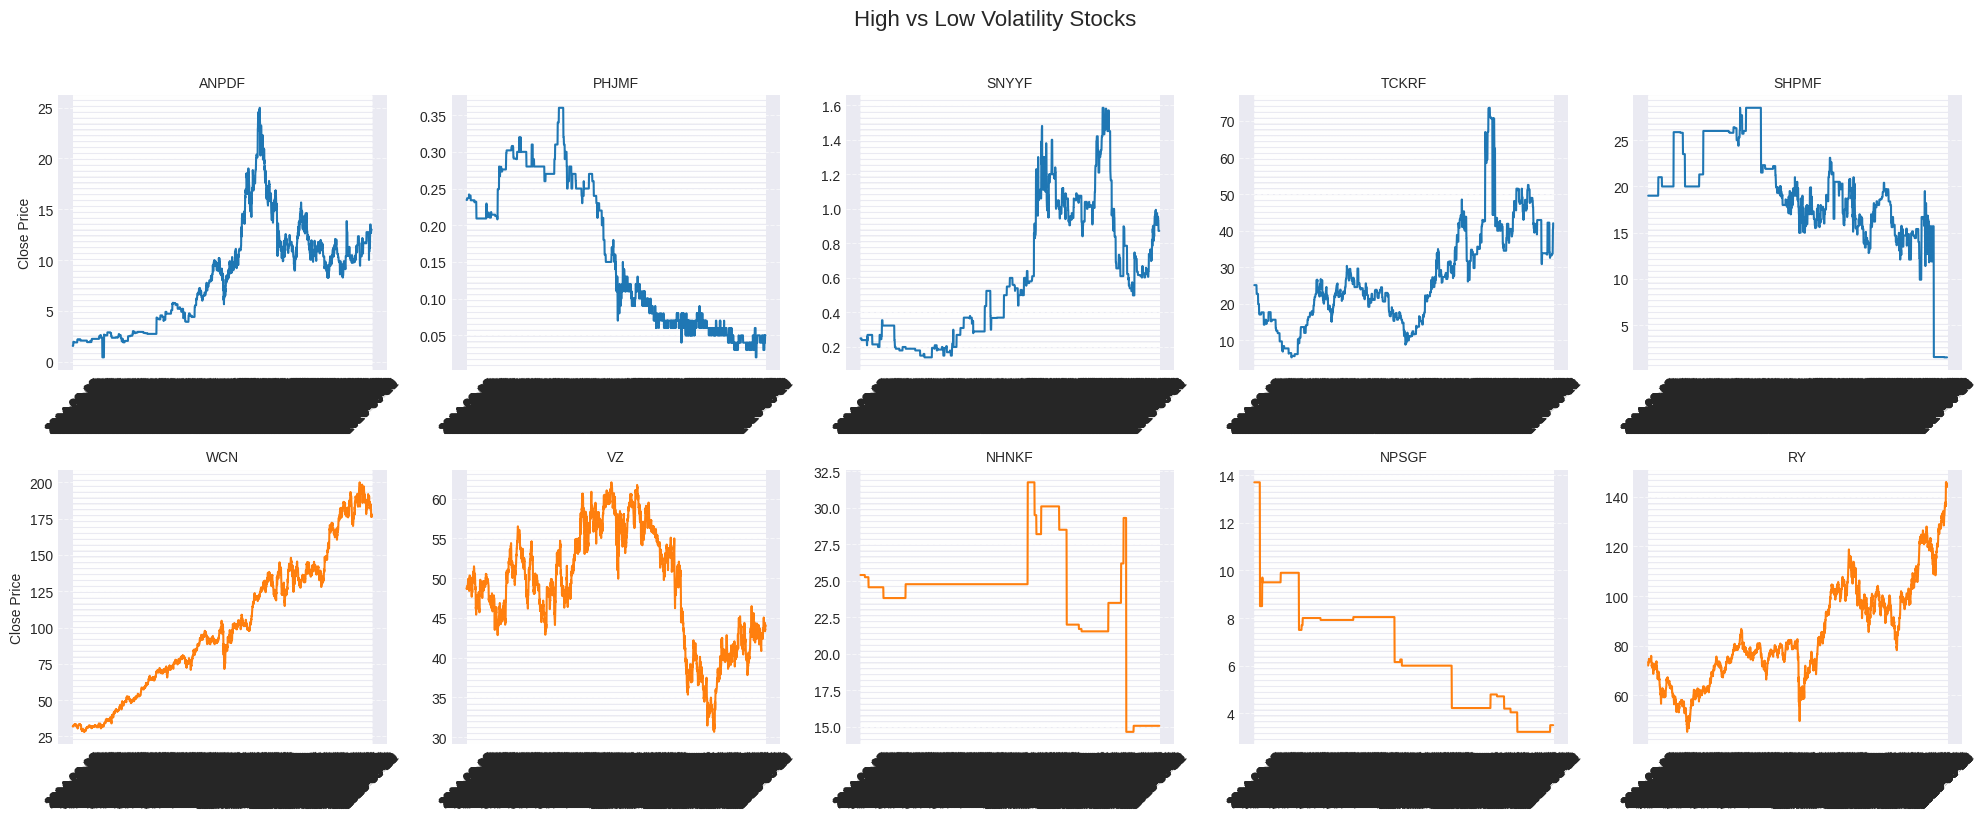

In [55]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=False)
fig.suptitle('High vs Low Volatility Stocks', fontsize=16, y=1.02)

# --- High Volatility Stocks (Top row) ---
for i in range(5):
    ticker = volatility_df['Ticker'].iloc[i]
    subset = df[df['Ticker'] == ticker]
    ax = axes[0, i]
    ax.plot(subset['Date'], subset['Close'], label=ticker, color='tab:blue')
    ax.set_title(f'{ticker}', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.tick_params(axis='x', rotation=45)
    if i == 0:
        ax.set_ylabel('Close Price')

# --- Low Volatility Stocks (Bottom row) ---
for i in range(5):
    ticker = volatility_df['Ticker'].iloc[-(i+1)]
    subset = df[df['Ticker'] == ticker]
    ax = axes[1, i]
    ax.plot(subset['Date'], subset['Close'], label=ticker, color='tab:orange')
    ax.set_title(f'{ticker}', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.tick_params(axis='x', rotation=45)
    if i == 0:
        ax.set_ylabel('Close Price')

plt.tight_layout()
plt.show()


In [56]:
### Identifying Spikey Tickers
# Threshold for "almost zero" returns
threshold = 0.001  # 0.1% return considered near-zero

# Calculate fraction of near-zero returns per ticker
flat_fraction = df_vol.groupby('Ticker')['Returns'].apply(
    lambda x: (x.abs() < threshold).sum() / x.count()
).reset_index(name='Flat_Fraction')

# Merge with overall volatility
volatility_df = volatility_df.merge(flat_fraction, on='Ticker')

# Set the quantile threshold (e.g., top 20%)
quantile_threshold = volatility_df['Flat_Fraction'].quantile(0.8)

# Identify candidate tickers
spiky_tickers = volatility_df[
    (volatility_df['Returns'] > volatility_df['Returns'].median()) &
    (volatility_df['Flat_Fraction'] >= quantile_threshold)
].sort_values(by='Flat_Fraction', ascending=False)

print(spiky_tickers)
print(len(spiky_tickers))



   Ticker  Returns  Flat_Fraction
40  TSIHF   0.0196         0.9039
22  GPAEF   0.0263         0.8907
36  CHFFF   0.0212         0.8867
3


In [48]:
spiky_tickers[spiky_tickers['Flat_Fraction'] > 0.9]['Ticker'].to_list()

['YTLCF', 'OLCLF']

In [38]:
# Average rolling volatility per ticker
# avg_rolling_vol = df_vol.groupby('Ticker')['Rolling_Volatility'].mean().reset_index(name='Avg_Rolling_Vol')
# volatility_df = volatility_df.merge(avg_rolling_vol, on='Ticker')

# # Identify tickers where overall volatility >> rolling average
# spiky_tickers = volatility_df[
#     (volatility_df['Returns'] > volatility_df['Avg_Rolling_Vol'] * 3)  # spikes
# ]
# print(spiky_tickers)


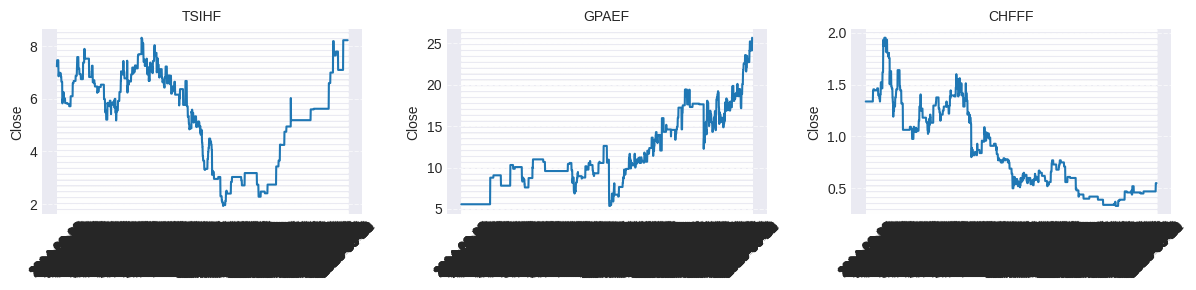

In [57]:
import math
import matplotlib.pyplot as plt

tickers = spiky_tickers['Ticker'].tolist()
n = len(tickers)
cols = 5
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3), sharex=False)
axes = axes.flatten()  # flatten in case we have multiple rows

for i, ticker in enumerate(tickers):
    subset = df_vol[df_vol['Ticker'] == ticker]
    axes[i].plot(subset['Date'], subset['Close'], label=ticker, color='tab:blue')
    axes[i].set_title(ticker, fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.6)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Close')

# Remove any unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Looking at Channels Analysis ###

In [2]:
import pandas as pd

# Example channel groups
columns = [
    ['Close'], # Close Prices
    ['dupont_net_margin', 'dupont_asset_turnover', 'dupont_equity_multiplier', 'dupont_roe'], # Dupont Analysis
    ['cashGenerationCapitalAllocation', 'growth', 'leverage', 'profitability', 'score'], # Earnings Quality Score 
    ['surprise_percent_quarterly'], # Surpisee Earnings percent quarterly
    ['social_sentiment_score'],
    ['change_vol'], # insider transactions change volume
    ['totalValue'], # usa spending history agg
    ['prev_monthly_share_purchase_ratio', 'net_change_insider_transactions'], # Insider Sentiment Purchase Ratio
    ['environmentScore', 'governanceScore','socialScore', 'totalESGScore'] # Historical ESG Scores 
]

channel_names = [f"channel_{i+1}" for i in range(len(columns))]

def count_non_nan_by_ticker(df, columns, channel_names):
    results = []

    for ticker, group in df.groupby("Ticker"):
        # total non-nan across all columns
        total_non_nan = group.notna().sum().sum()

        # per-channel non-nan counts
        channel_counts = [group[c].notna().sum().sum() / len(c) for c in columns]

        # combine results
        result = {"Ticker": ticker, "total_non_nan": total_non_nan}
        result.update({name: count for name, count in zip(channel_names, channel_counts)})
        results.append(result)

    # convert to DataFrame
    res_df = pd.DataFrame(results)

    # sort by total non-nan descending
    res_df = res_df.sort_values("total_non_nan", ascending=False).reset_index(drop=True)
    return res_df

# Run the function
ticker_nan_summary = count_non_nan_by_ticker(df, columns, channel_names)
print(ticker_nan_summary.head(10))


  Ticker  total_non_nan  channel_1  channel_2  channel_3  channel_4  \
0   TMUS          27168  2791.0000    31.0000    31.0000     4.0000   
1    PPG          27079  2791.0000    31.0000    31.0000     4.0000   
2   MSFT          27050  2791.0000    31.0000    31.0000     4.0000   
3      A          27035  2791.0000    31.0000    31.0000     3.0000   
4    WMT          26104  2791.0000    31.0000    31.0000     3.0000   
5     VZ          25918  2791.0000    31.0000    31.0000     4.0000   
6    ROK          25736  2791.0000    31.0000    31.0000     4.0000   
7    PSX          25688  2791.0000    31.0000    31.0000     4.0000   
8    ICE          25465  2791.0000    31.0000    31.0000     4.0000   
9    DUK          25343  2791.0000    31.0000    31.0000     4.0000   

   channel_5  channel_6  channel_7  channel_8  channel_9  
0   154.0000   332.0000  2203.0000    56.0000     0.0000  
1    67.0000   377.0000  2015.0000    43.0000     0.0000  
2    25.0000   367.0000  1960.0000    73.

In [3]:
ticker_nan_summary['Full Sum'] = ticker_nan_summary[channel_names].sum(axis=1)
ticker_nan_summary = ticker_nan_summary.sort_values('Full Sum', ascending=False).reset_index(drop=True)
print(ticker_nan_summary.head(10))


  Ticker  total_non_nan  channel_1  channel_2  channel_3  channel_4  \
0   TMUS          27168  2791.0000    31.0000    31.0000     4.0000   
1      A          27035  2791.0000    31.0000    31.0000     3.0000   
2    PPG          27079  2791.0000    31.0000    31.0000     4.0000   
3   MSFT          27050  2791.0000    31.0000    31.0000     4.0000   
4    PSX          25688  2791.0000    31.0000    31.0000     4.0000   
5    DUK          25343  2791.0000    31.0000    31.0000     4.0000   
6    ROK          25736  2791.0000    31.0000    31.0000     4.0000   
7  ITOCF          23988  2791.0000    31.0000     0.0000     4.0000   
8    NRG          24633  2791.0000    31.0000    31.0000     4.0000   
9     VZ          25918  2791.0000    31.0000    31.0000     4.0000   

   channel_5  channel_6  channel_7  channel_8  channel_9  Full Sum  
0   154.0000   332.0000  2203.0000    56.0000     0.0000 5602.0000  
1    17.0000   302.0000  2340.0000    62.0000     0.0000 5577.0000  
2    67.000

In [4]:
ticker_nan_summary

,Ticker,total_non_nan,channel_1,channel_2,channel_3,channel_4,channel_5,channel_6,channel_7,channel_8,channel_9,Full Sum
0,TMUS,27168,2791.0000,31.0000,31.0000,4.0000,154.0000,332.0000,2203.0000,56.0000,0.0000,5602.0000
1,A,27035,2791.0000,31.0000,31.0000,3.0000,17.0000,302.0000,2340.0000,62.0000,0.0000,5577.0000
2,PPG,27079,2791.0000,31.0000,31.0000,4.0000,67.0000,377.0000,2015.0000,43.0000,0.0000,5359.0000
3,MSFT,27050,2791.0000,31.0000,31.0000,4.0000,25.0000,367.0000,1960.0000,73.0000,7.0000,5289.0000
4,PSX,25688,2791.0000,31.0000,31.0000,4.0000,184.0000,212.0000,1314.0000,49.0000,0.0000,4616.0000
...,...,...,...,...,...,...,...,...,...,...,...,...
77,JGCCF,22584,2791.0000,16.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2807.0000
78,SLMAF,22524,2791.0000,15.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2807.0000
79,SNYYF,22568,2791.0000,15.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2806.0000
80,MDNDF,22568,2791.0000,15.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2806.0000


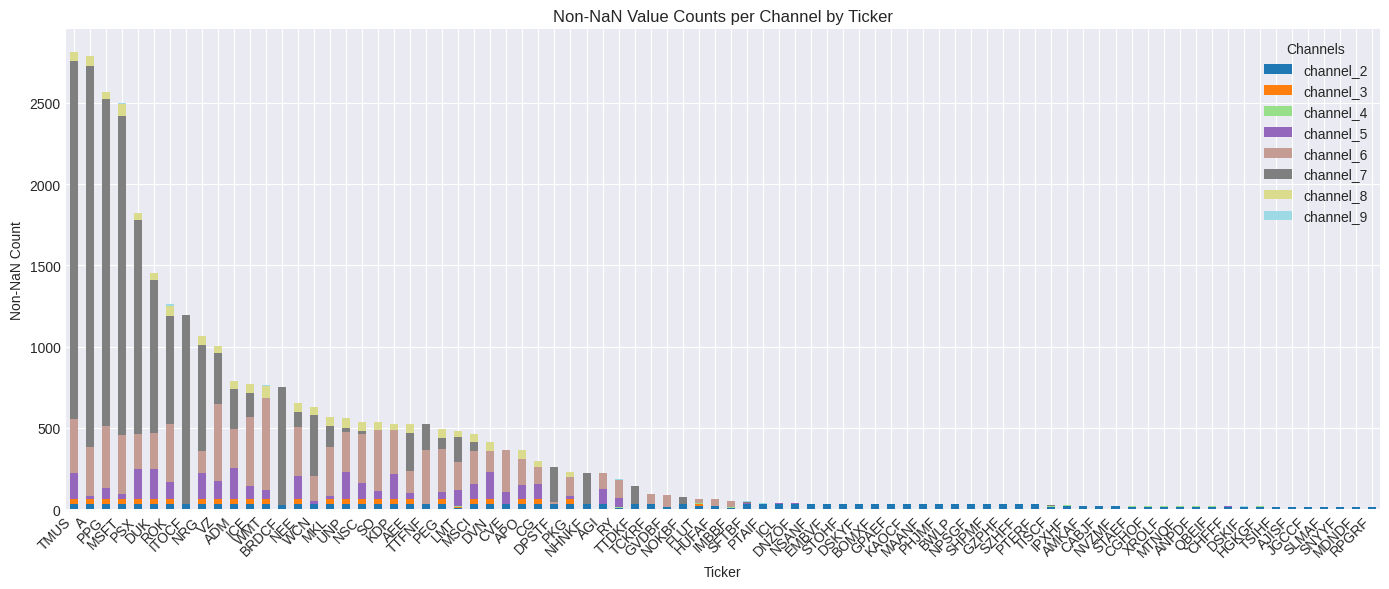

In [5]:
import matplotlib.pyplot as plt

columns = [
    ['Close'], # Close Prices
    ['dupont_net_margin', 'dupont_asset_turnover', 'dupont_equity_multiplier', 'dupont_roe'], # Dupont Analysis
    ['cashGenerationCapitalAllocation', 'growth', 'leverage', 'profitability', 'score'], # Earnings Quality Score 
    ['surprise_percent_quarterly'], # Surpisee Earnings percent quarterly
    ['social_sentiment_score'],
    ['change_vol'], # insider transactions change volume
    ['totalValue'], # usa spending history agg
    ['prev_monthly_share_purchase_ratio', 'net_change_insider_transactions'], # Insider Sentiment Purchase Ratio
    ['environmentScore', 'governanceScore','socialScore', 'totalESGScore'] # Historical ESG Scores 
]



# Select top N tickers to plot
top_n = 100
df_plot = ticker_nan_summary.head(top_n).set_index("Ticker")

# Identify channel columns automatically
channel_cols = [col for col in df_plot.columns if col.startswith("channel_") and col != 'channel_1']

# Plot stacked bar chart
df_plot[channel_cols].plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6),
    colormap="tab20"
)

plt.title("Non-NaN Value Counts per Channel by Ticker")
plt.xlabel("Ticker")
plt.ylabel("Non-NaN Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Channels")
plt.tight_layout()
plt.show()


In [10]:
ticker_nan_summary['Ticker'].to_list()


# Save the top 100 tickers to a text file
top_100_tickers = ticker_nan_summary['Ticker'].head(100).to_list()
with open('top_100_tickers.txt', 'w') as f:
    for ticker in top_100_tickers:
        f.write(f"{ticker}\n")


#### 1. DataFrame Overview ###


1. DATA OVERVIEW

Dataset Shape: 323,756 rows × 44 columns
Date Range: 2014-08-08 00:00:00 to 2025-09-12 00:00:00
Number of Unique Tickers: 116
Memory Usage: 125.17 MB

Ticker Coverage Statistics:
  Mean records per ticker: 2791
  Median records per ticker: 2791
  Min records per ticker: 2791
  Max records per ticker: 2791

Sample Ticker Coverage:
Ticker  Num_Records Start_Date   End_Date  Days_Coverage
     A         2791 2014-08-08 2025-09-12           4053
  AAPL         2791 2014-08-08 2025-09-12           4053
 ACPIF         2791 2014-08-08 2025-09-12           4053
   ADM         2791 2014-08-08 2025-09-12           4053
   AEE         2791 2014-08-08 2025-09-12           4053
   AGI         2791 2014-08-08 2025-09-12           4053
 AITUF         2791 2014-08-08 2025-09-12           4053
 AJISF         2791 2014-08-08 2025-09-12           4053
 AKBLF         2791 2014-08-08 2025-09-12           4053
 AMKAF         2791 2014-08-08 2025-09-12           4053


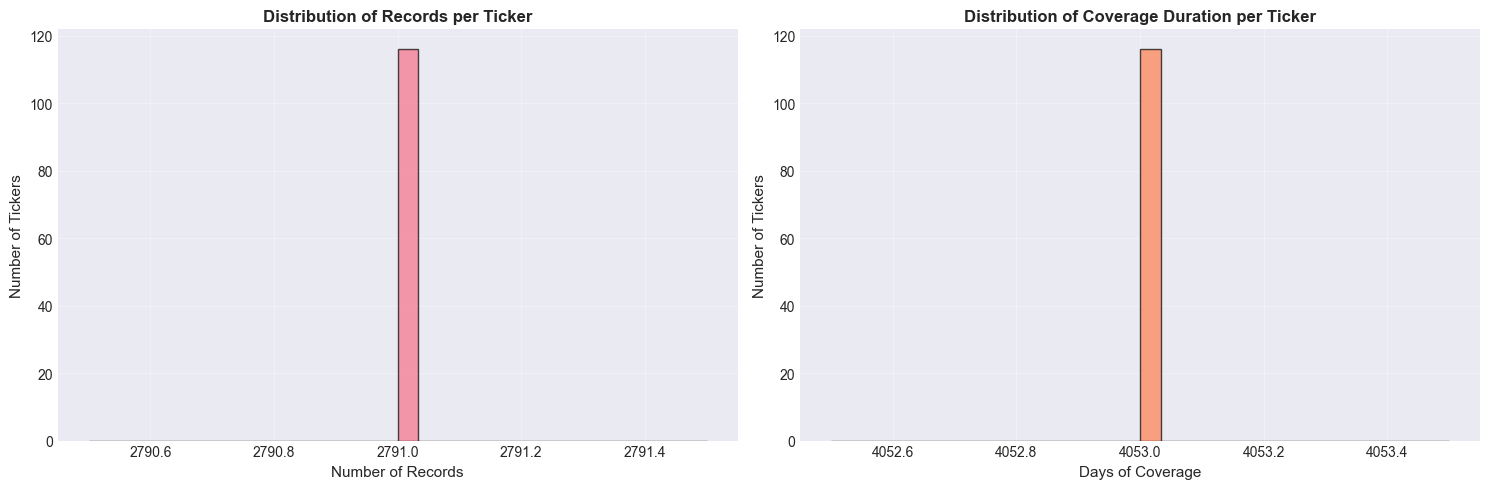

In [92]:
print("\n" + "=" * 80)
print("1. DATA OVERVIEW")
print("=" * 80)

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

print(f"\nDataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Number of Unique Tickers: {df['Ticker'].nunique()}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Ticker-level statistics
ticker_stats = df.groupby('Ticker').agg({
    'Date': ['count', 'min', 'max']
}).reset_index()
ticker_stats.columns = ['Ticker', 'Num_Records', 'Start_Date', 'End_Date']
ticker_stats['Days_Coverage'] = (ticker_stats['End_Date'] - ticker_stats['Start_Date']).dt.days

print(f"\nTicker Coverage Statistics:")
print(f"  Mean records per ticker: {ticker_stats['Num_Records'].mean():.0f}")
print(f"  Median records per ticker: {ticker_stats['Num_Records'].median():.0f}")
print(f"  Min records per ticker: {ticker_stats['Num_Records'].min():.0f}")
print(f"  Max records per ticker: {ticker_stats['Num_Records'].max():.0f}")

# Show sample tickers
print(f"\nSample Ticker Coverage:")
print(ticker_stats.head(10).to_string(index=False))

# Visualize ticker coverage
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Records per ticker
axes[0].hist(ticker_stats['Num_Records'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Records', fontsize=11)
axes[0].set_ylabel('Number of Tickers', fontsize=11)
axes[0].set_title('Distribution of Records per Ticker', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Days coverage per ticker
axes[1].hist(ticker_stats['Days_Coverage'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Days of Coverage', fontsize=11)
axes[1].set_ylabel('Number of Tickers', fontsize=11)
axes[1].set_title('Distribution of Coverage Duration per Ticker', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2. Feature Categorization ###

In [93]:
print("\n" + "=" * 80)
print("2. FEATURE CATEGORIZATION")
print("=" * 80)

# Categorize features by type
price_features = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
fundamental_scores = ['cashGenerationCapitalAllocation', 'growth', 'leverage', 
                      'profitability', 'score']
earnings_features = ['surprise_percent_quarterly', 'revenue_growth']
financial_metrics = ['gross_profit', 'operating_profit', 'net_profit', 
                     'gross_margin', 'operating_margin', 'net_margin',
                     'current_ratio', 'quick_ratio', 'roa', 'roe', 'debt_equity']
dupont_features = ['dupont_net_margin', 'dupont_asset_turnover', 
                   'dupont_equity_multiplier', 'dupont_roe']
esg_features = ['environmentScore', 'governanceScore', 'socialScore', 'totalESGScore']
insider_features = ['net_change_insider_transactions', 'monthly_share_purchase_ratio',
                    'prev_monthly_share_purchase_ratio', 'before_share', 'change',
                    'share', 'change_vol', 'transactionPrice']
sentiment_features = ['social_sentiment_score', 'totalValue']

feature_categories = {
    'Price Data': price_features,
    'Fundamental Scores': fundamental_scores,
    'Earnings Metrics': earnings_features,
    'Financial Ratios': financial_metrics,
    'DuPont Analysis': dupont_features,
    'ESG Scores': esg_features,
    'Insider Trading': insider_features,
    'Sentiment': sentiment_features
}

for category, features in feature_categories.items():
    print(f"\n{category}: {len(features)} features")
    print(f"  {', '.join(features)}")


2. FEATURE CATEGORIZATION

Price Data: 6 features
  Open, High, Low, Close, Adj Close, Volume

Fundamental Scores: 5 features
  cashGenerationCapitalAllocation, growth, leverage, profitability, score

Earnings Metrics: 2 features
  surprise_percent_quarterly, revenue_growth

Financial Ratios: 11 features
  gross_profit, operating_profit, net_profit, gross_margin, operating_margin, net_margin, current_ratio, quick_ratio, roa, roe, debt_equity

DuPont Analysis: 4 features
  dupont_net_margin, dupont_asset_turnover, dupont_equity_multiplier, dupont_roe

ESG Scores: 4 features
  environmentScore, governanceScore, socialScore, totalESGScore

Insider Trading: 8 features
  net_change_insider_transactions, monthly_share_purchase_ratio, prev_monthly_share_purchase_ratio, before_share, change, share, change_vol, transactionPrice

Sentiment: 2 features
  social_sentiment_score, totalValue


### 3. Missing Data per Ticker ###

In [94]:
print("\n" + "=" * 80)
print("3. MISSING DATA ANALYSIS (ACROSS ALL TICKERS)")
print("=" * 80)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Overall missing data
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df) * 100)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values(
    'Missing_Percent', ascending=False
)

if len(missing_data) > 0:
    print("\nColumns with Missing Values (Overall):")
    print(missing_data.to_string(index=False))
else:
    print("\nNo missing values found in the dataset!")

# Missing data by ticker
print("\n" + "-" * 80)
print("Missing Data Analysis by Ticker")
print("-" * 80)

missing_by_ticker = []
for ticker in df['Ticker'].unique():
    ticker_df = df[df['Ticker'] == ticker]
    for col in numeric_cols:
        missing_count = ticker_df[col].isnull().sum()
        if missing_count > 0:
            missing_by_ticker.append({
                'Ticker': ticker,
                'Feature': col,
                'Missing_Count': missing_count,
                'Missing_Percent': missing_count / len(ticker_df) * 100
            })

if missing_by_ticker:
    missing_ticker_df = pd.DataFrame(missing_by_ticker).sort_values(
        'Missing_Percent', ascending=False
    )
    print(f"\nTop 20 Ticker-Feature combinations with highest missing %:")
    print(missing_ticker_df.head(20).to_string(index=False))
    
    # Visualize missing data patterns
    pivot_missing = missing_ticker_df.pivot_table(
        index='Feature', columns='Ticker', values='Missing_Percent', fill_value=0
    )
    
    if pivot_missing.shape[1] <= 50:  # Only plot if reasonable number of tickers
        plt.figure(figsize=(16, 10))
        sns.heatmap(pivot_missing, cmap='YlOrRd', cbar_kws={'label': 'Missing %'})
        plt.title('Missing Data Heatmap by Ticker and Feature', fontsize=14, fontweight='bold')
        plt.xlabel('Ticker', fontsize=11)
        plt.ylabel('Feature', fontsize=11)
        plt.tight_layout()
        plt.show()
else:
    print("\nNo missing values found at ticker level!")


3. MISSING DATA ANALYSIS (ACROSS ALL TICKERS)



Columns with Missing Values (Overall):
                         Column  Missing_Count  Missing_Percent
                governanceScore         319416          98.6595
               environmentScore         319416          98.6595
                  totalESGScore         319416          98.6595
                    socialScore         319416          98.6595
     surprise_percent_quarterly         300343          92.7683
                          score         268600          82.9637
                         growth         268600          82.9637
                       leverage         268600          82.9637
                  profitability         268600          82.9637
cashGenerationCapitalAllocation         268600          82.9637
                    quick_ratio         161081          49.7538
                   gross_margin         149601          46.2079
                   gross_profit         149601          46.2079
                  current_ratio         133543          41.2480


### 4. Descriptive Statistics ###

In [95]:
print("\n" + "=" * 80)
print("4. DESCRIPTIVE STATISTICS")
print("=" * 80)

# Pooled statistics (across all tickers)
print("\n" + "-" * 80)
print("POOLED STATISTICS (All Tickers Combined)")
print("-" * 80)

desc_stats_pooled = df[numeric_cols].describe().T
desc_stats_pooled['median'] = df[numeric_cols].median()
desc_stats_pooled['skewness'] = df[numeric_cols].apply(lambda x: skew(x.dropna()))
desc_stats_pooled['kurtosis'] = df[numeric_cols].apply(lambda x: kurtosis(x.dropna()))
desc_stats_pooled['zeros_pct'] = (df[numeric_cols] == 0).sum() / len(df) * 100

print("\nPooled Descriptive Statistics (first 15 features):")
print(desc_stats_pooled.head(15).to_string())

# Per-ticker statistics (aggregated)
print("\n" + "-" * 80)
print("PER-TICKER STATISTICS (Variation Across Tickers)")
print("-" * 80)

ticker_variation = []
for col in numeric_cols:
    ticker_means = df.groupby('Ticker')[col].mean()
    ticker_stds = df.groupby('Ticker')[col].std()
    
    ticker_variation.append({
        'Feature': col,
        'Mean_of_Ticker_Means': ticker_means.mean(),
        'Std_of_Ticker_Means': ticker_means.std(),
        'CV_Across_Tickers': ticker_means.std() / abs(ticker_means.mean()) if ticker_means.mean() != 0 else np.inf,
        'Min_Ticker_Mean': ticker_means.min(),
        'Max_Ticker_Mean': ticker_means.max()
    })

ticker_var_df = pd.DataFrame(ticker_variation)
ticker_var_df = ticker_var_df.replace([np.inf, -np.inf], np.nan)
print("\nVariation of Features Across Tickers (first 15):")
print(ticker_var_df.head(15).to_string(index=False))


4. DESCRIPTIVE STATISTICS

--------------------------------------------------------------------------------
POOLED STATISTICS (All Tickers Combined)
--------------------------------------------------------------------------------

Pooled Descriptive Statistics (first 15 features):
                                      count                     mean                       std                          min       25%       50%         75%                       max    median  skewness  kurtosis  zeros_pct
Open                            323756.0000                  98.1537                  363.2920                       0.0001    5.2093   18.6500     56.8700                 5337.0000   18.6500    8.0551   77.6746     0.0000
High                            323756.0000                  98.6845                  364.1100                       0.0001    5.2200   18.7000     57.3400                 5337.0000   18.7000    8.0298   77.2193     0.0000
Low                             323756.0000     

### 5. Pooled Distribution Analysis ### 


5. DISTRIBUTION ANALYSIS (POOLED ACROSS TICKERS)

PRICE DATA


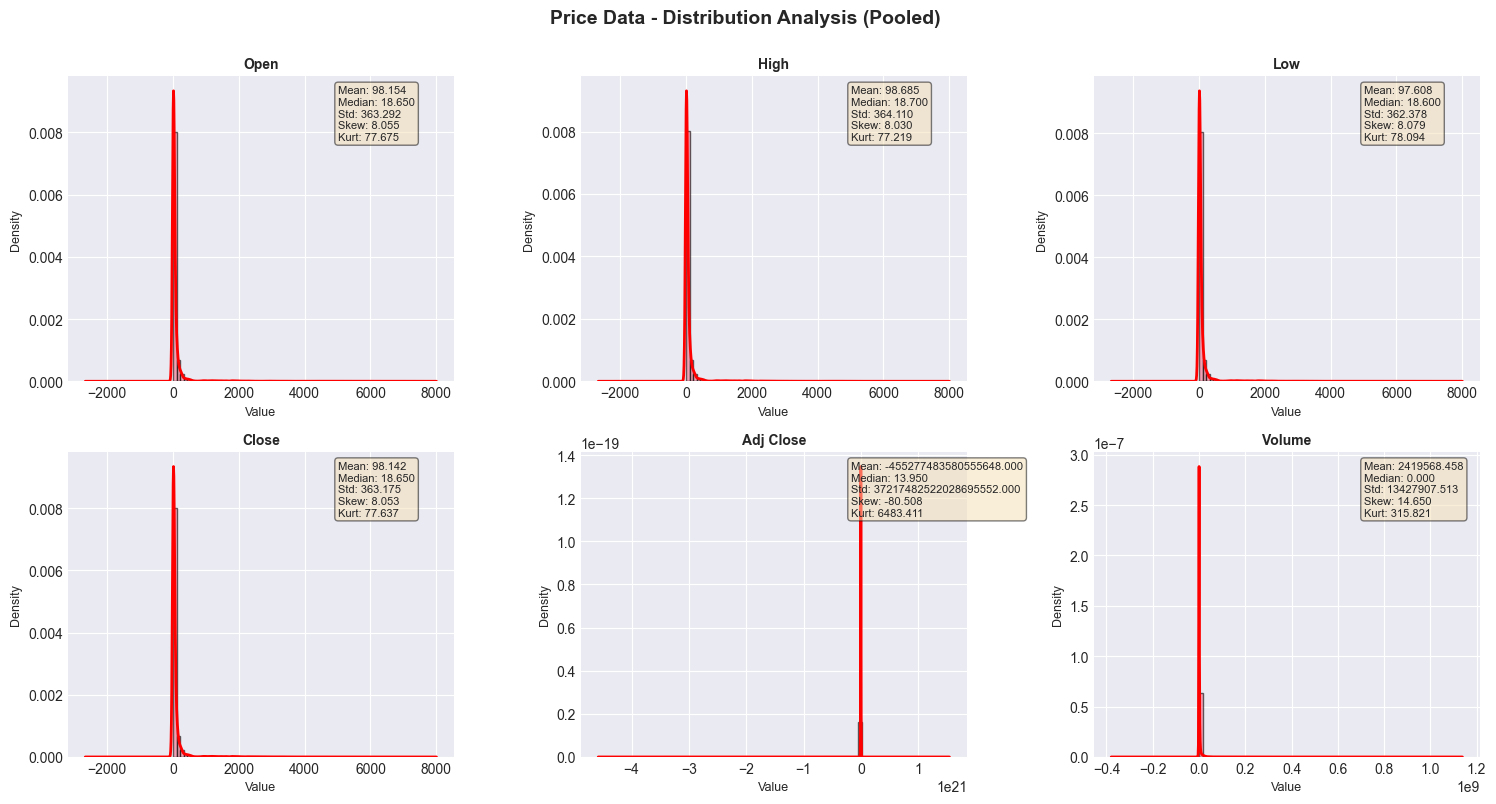

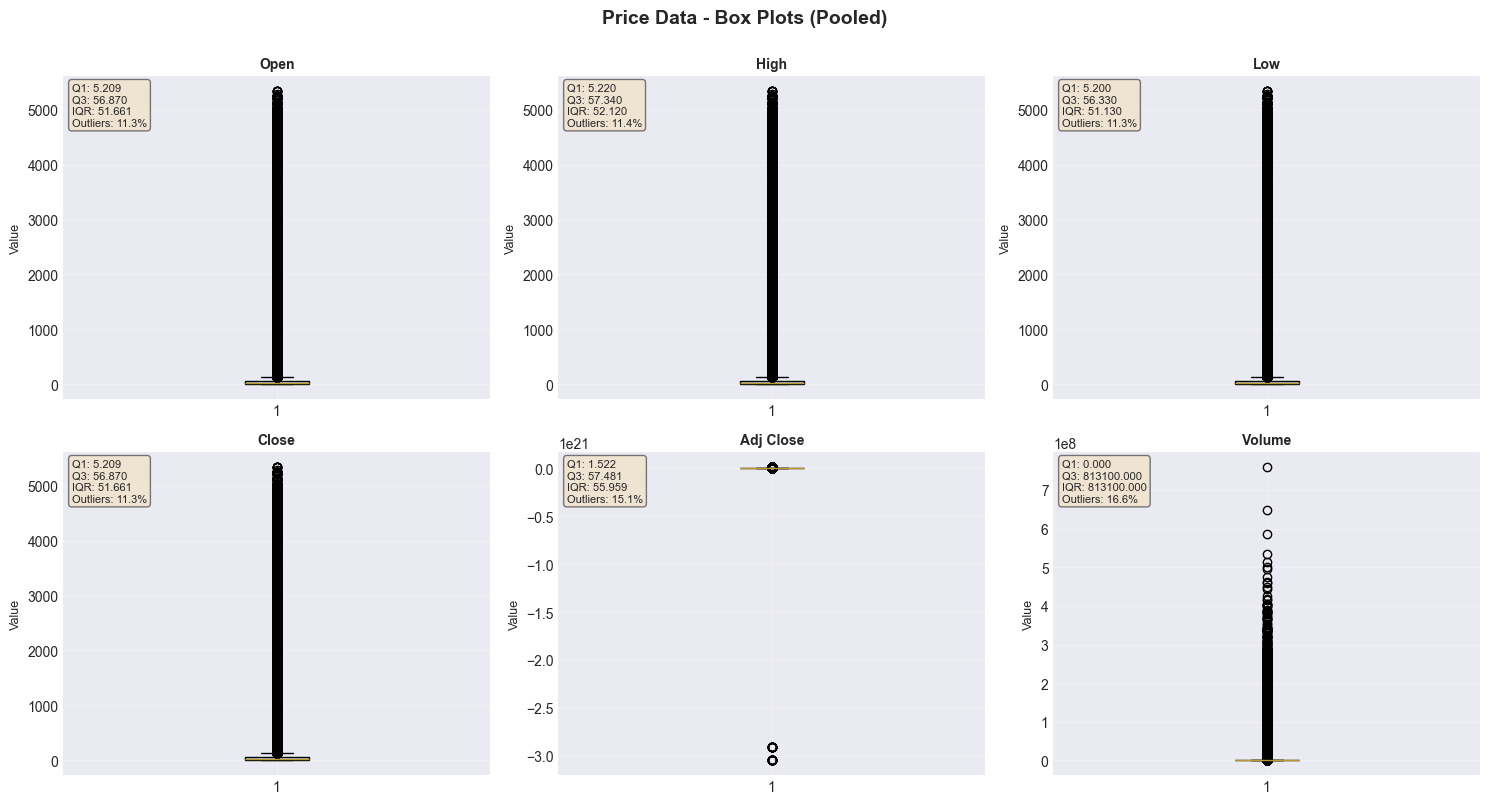


FUNDAMENTAL SCORES


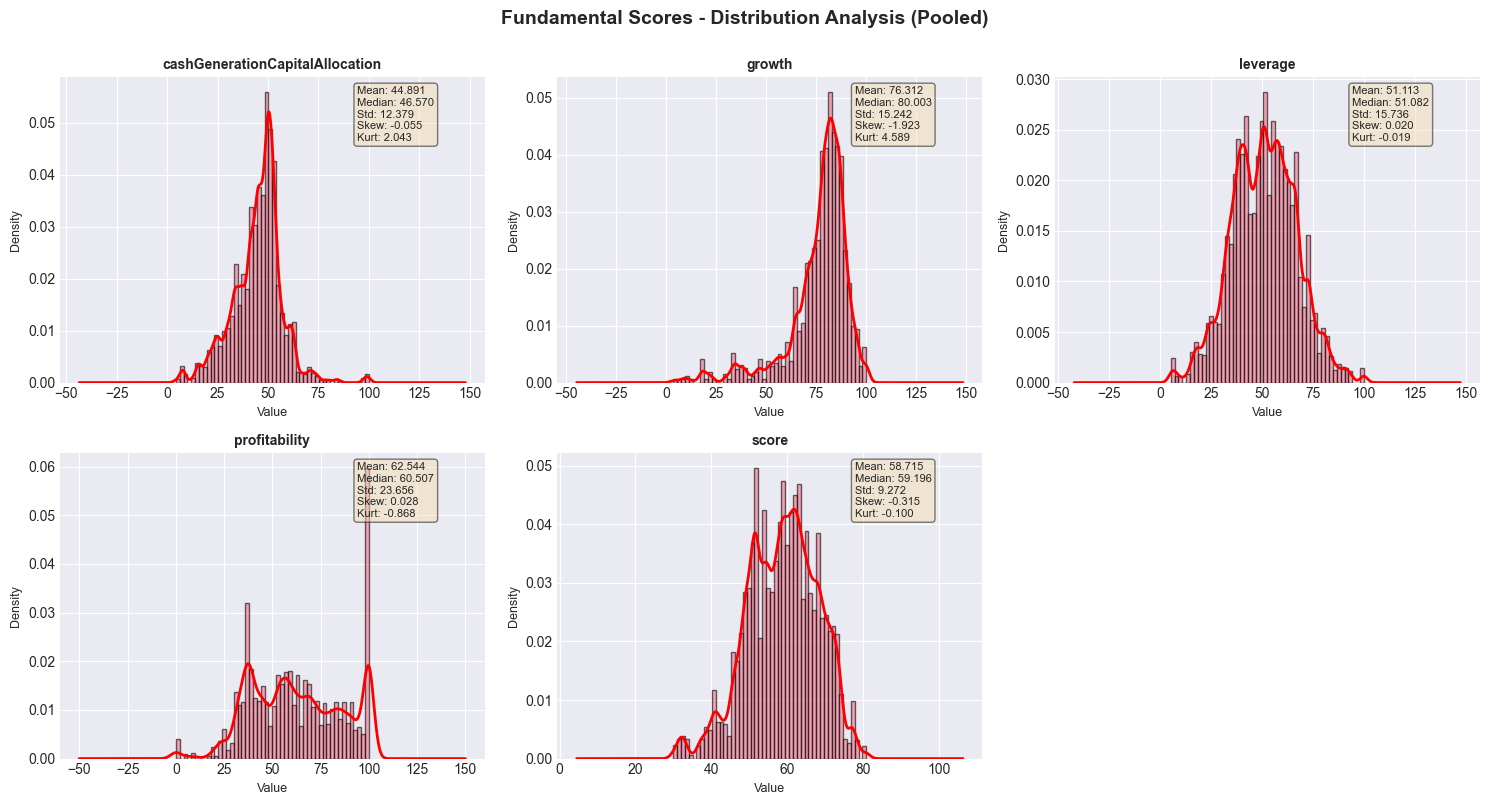

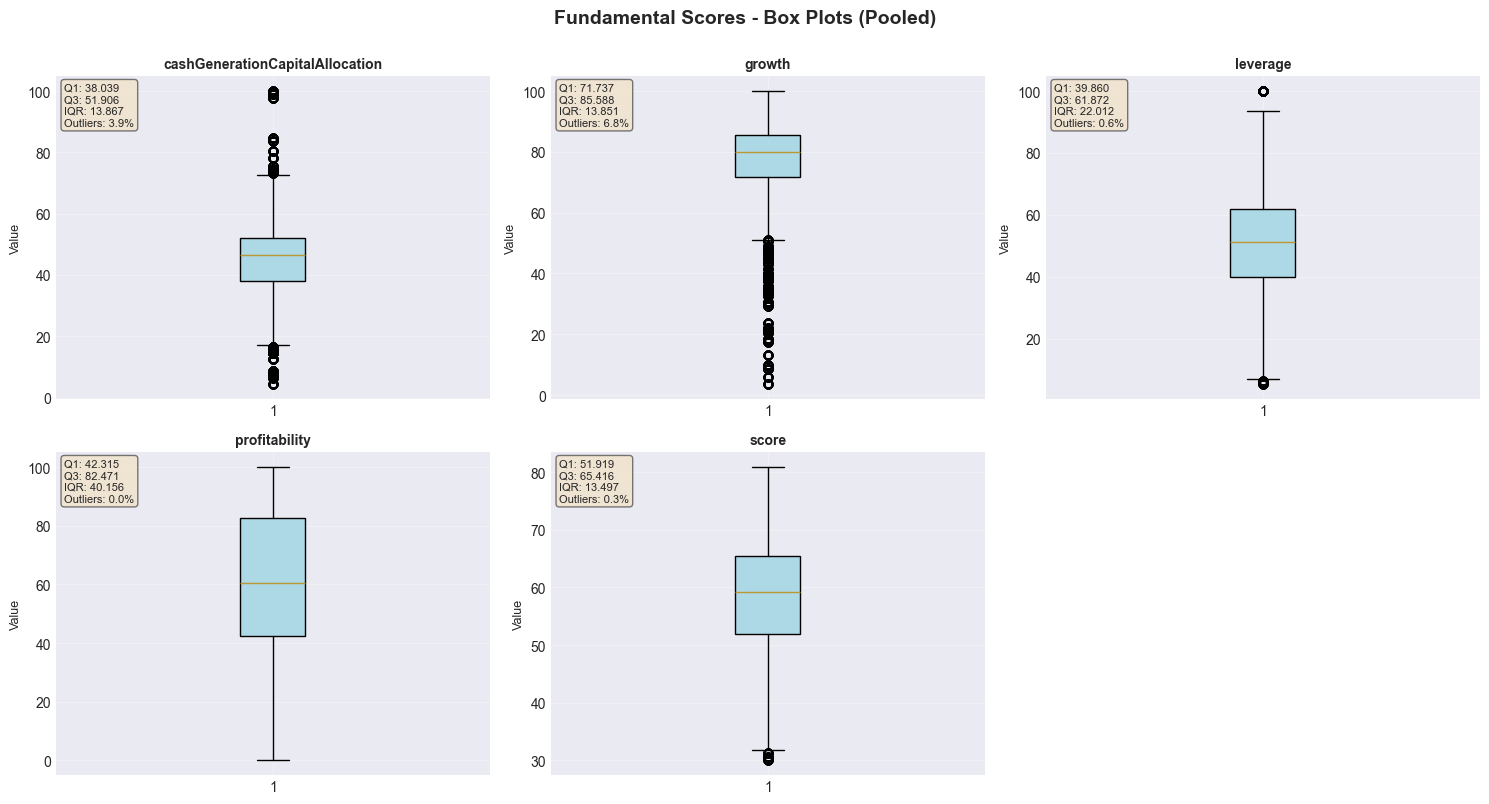


EARNINGS METRICS


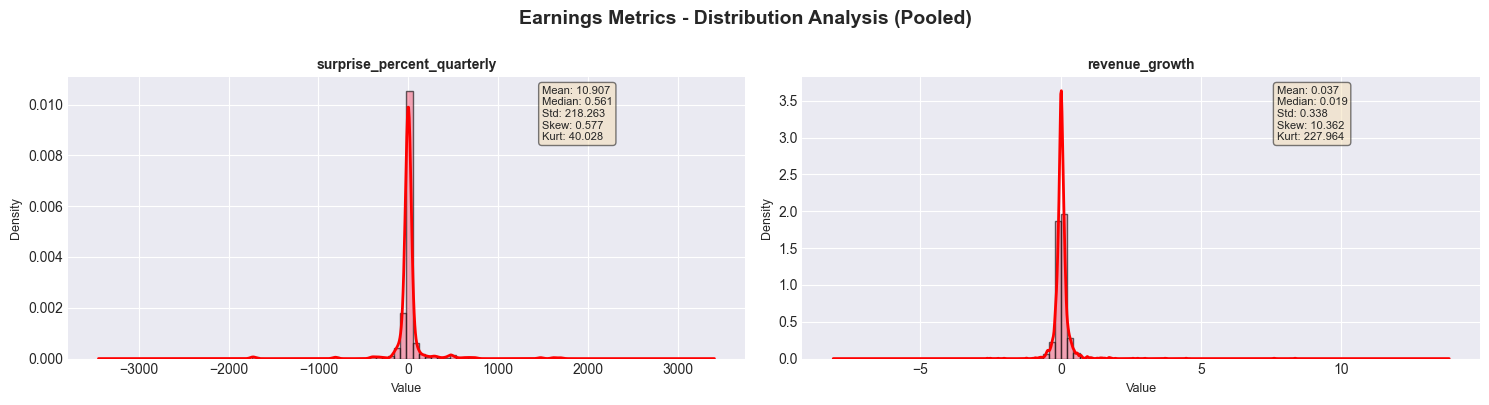

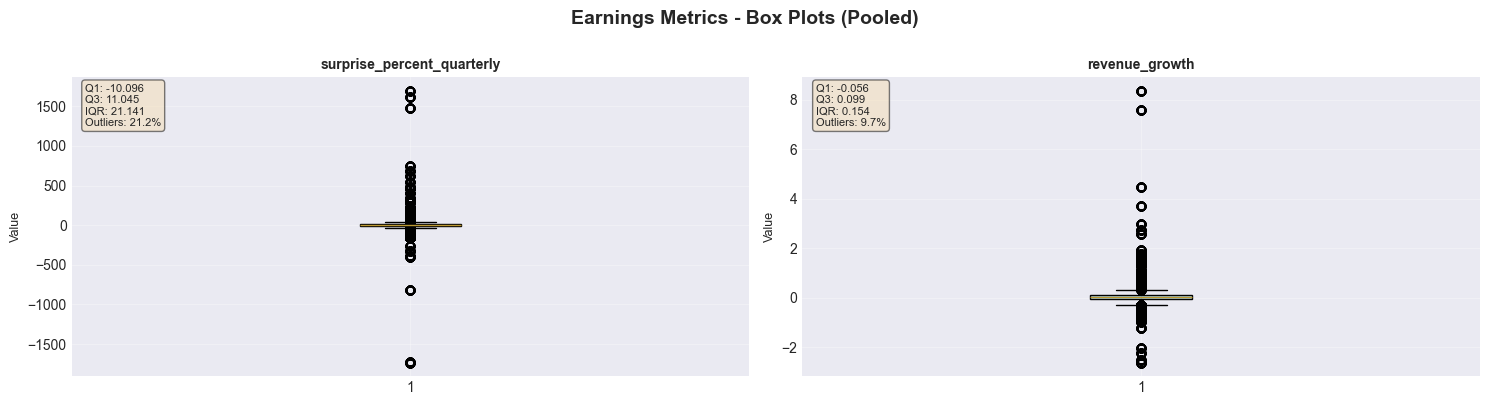


FINANCIAL RATIOS


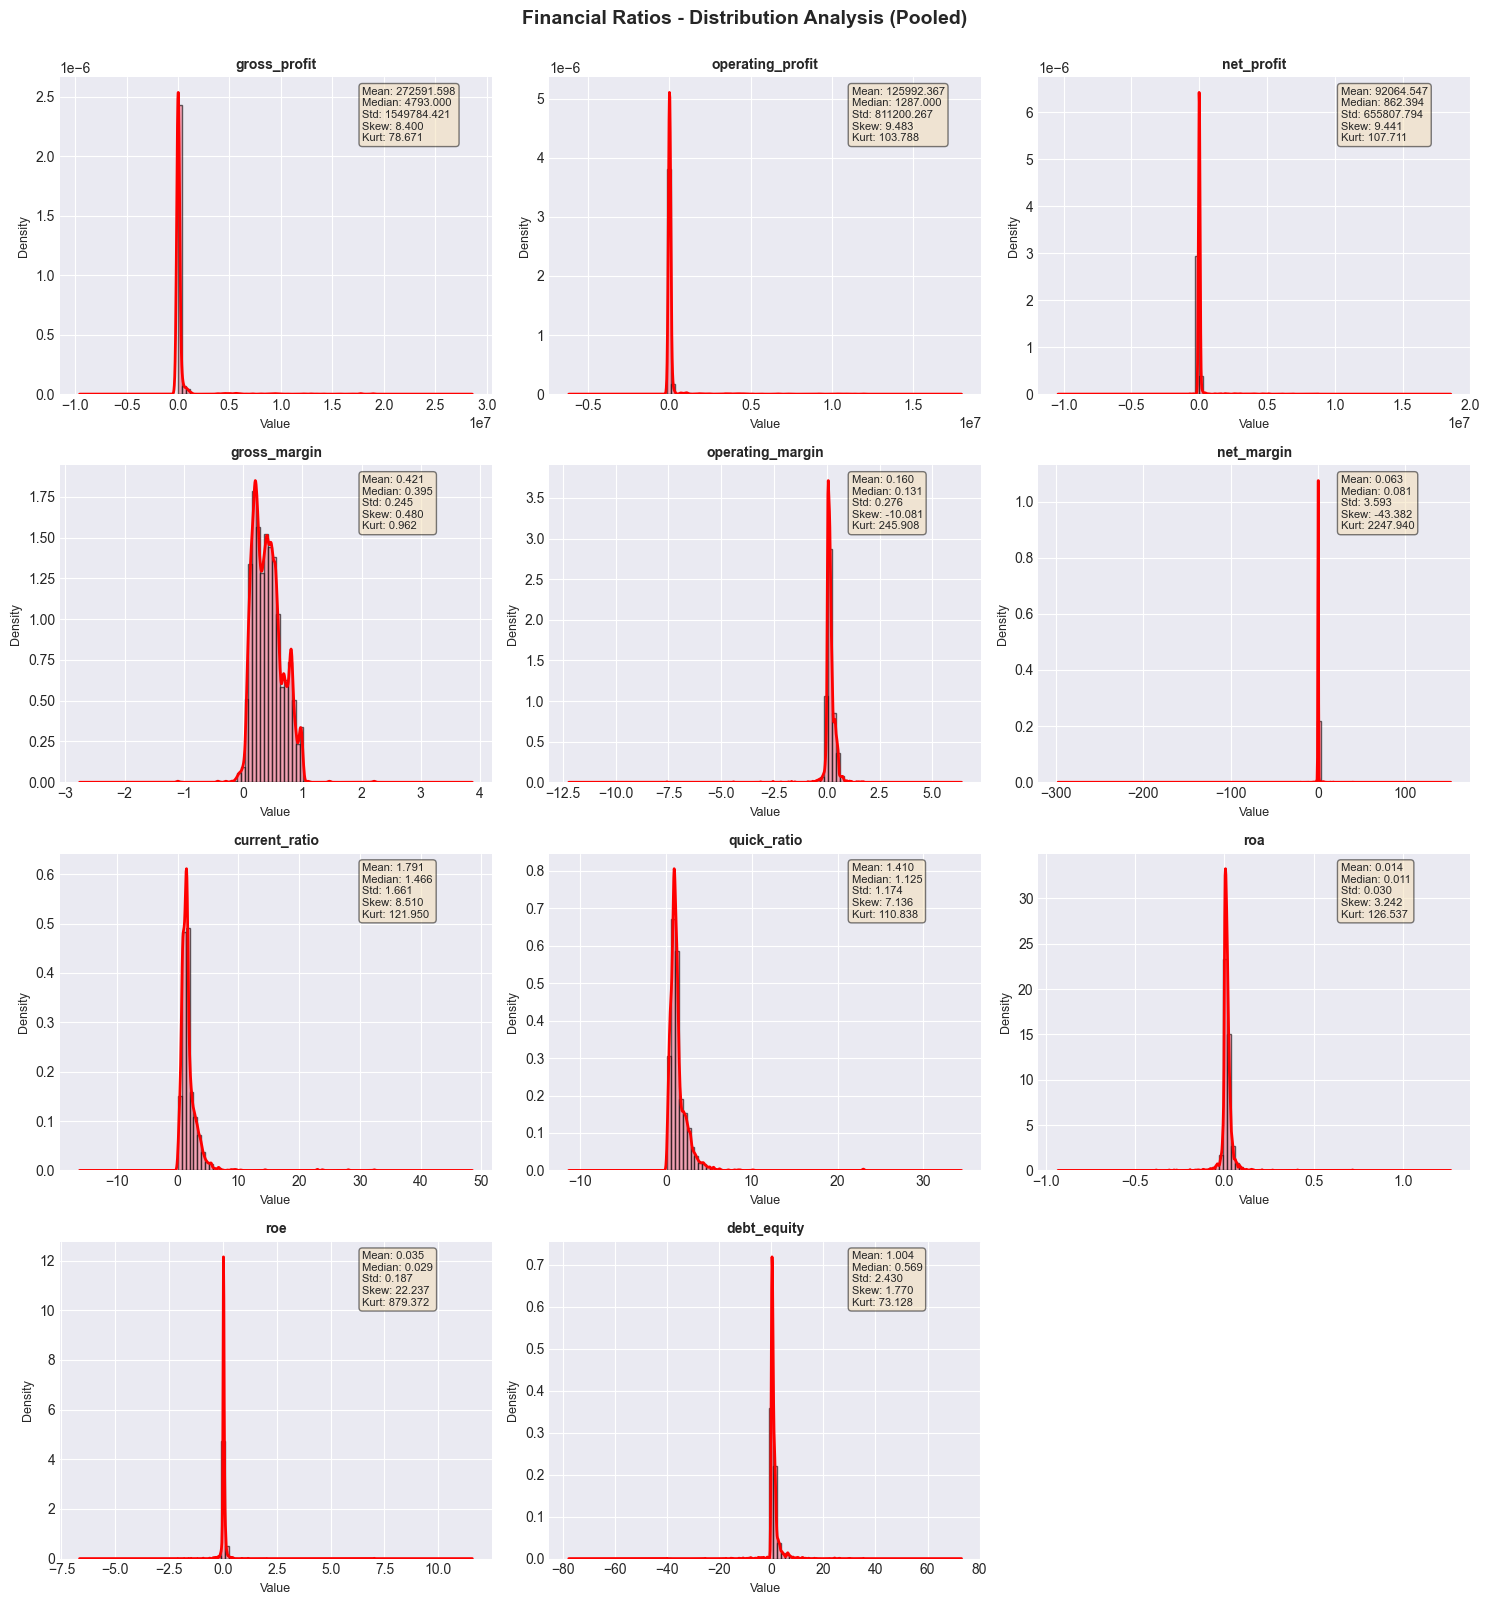

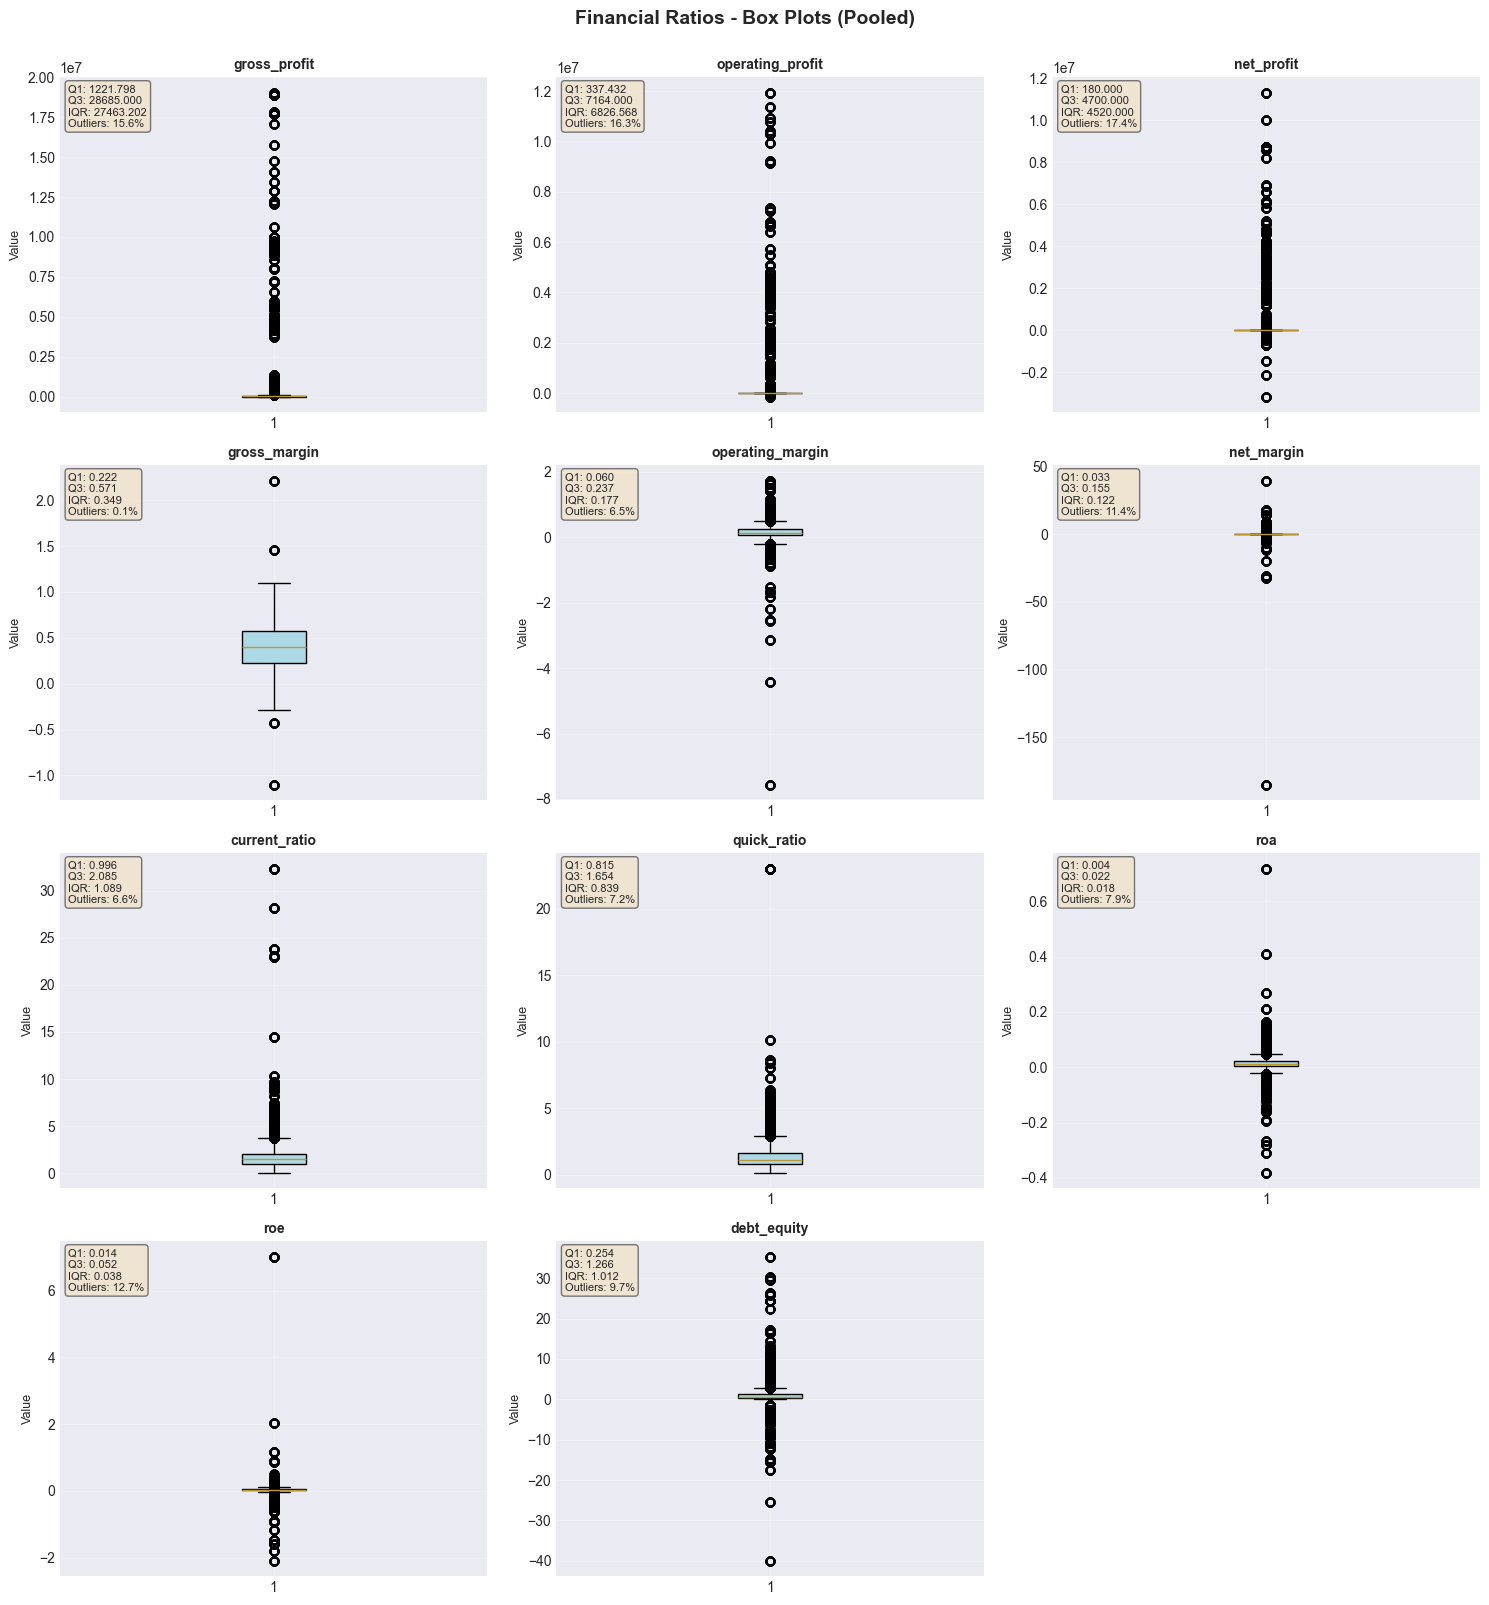


DUPONT ANALYSIS


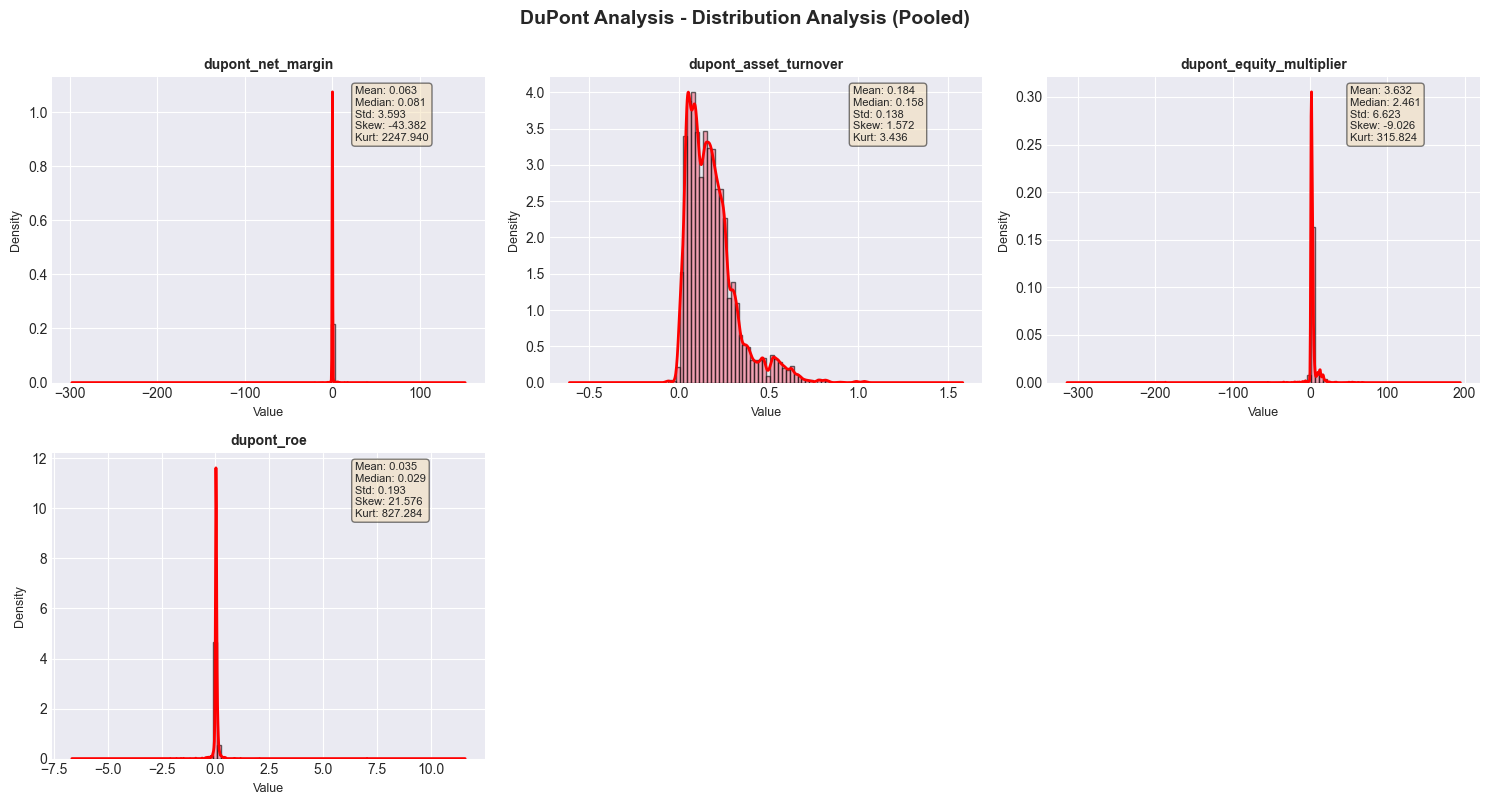

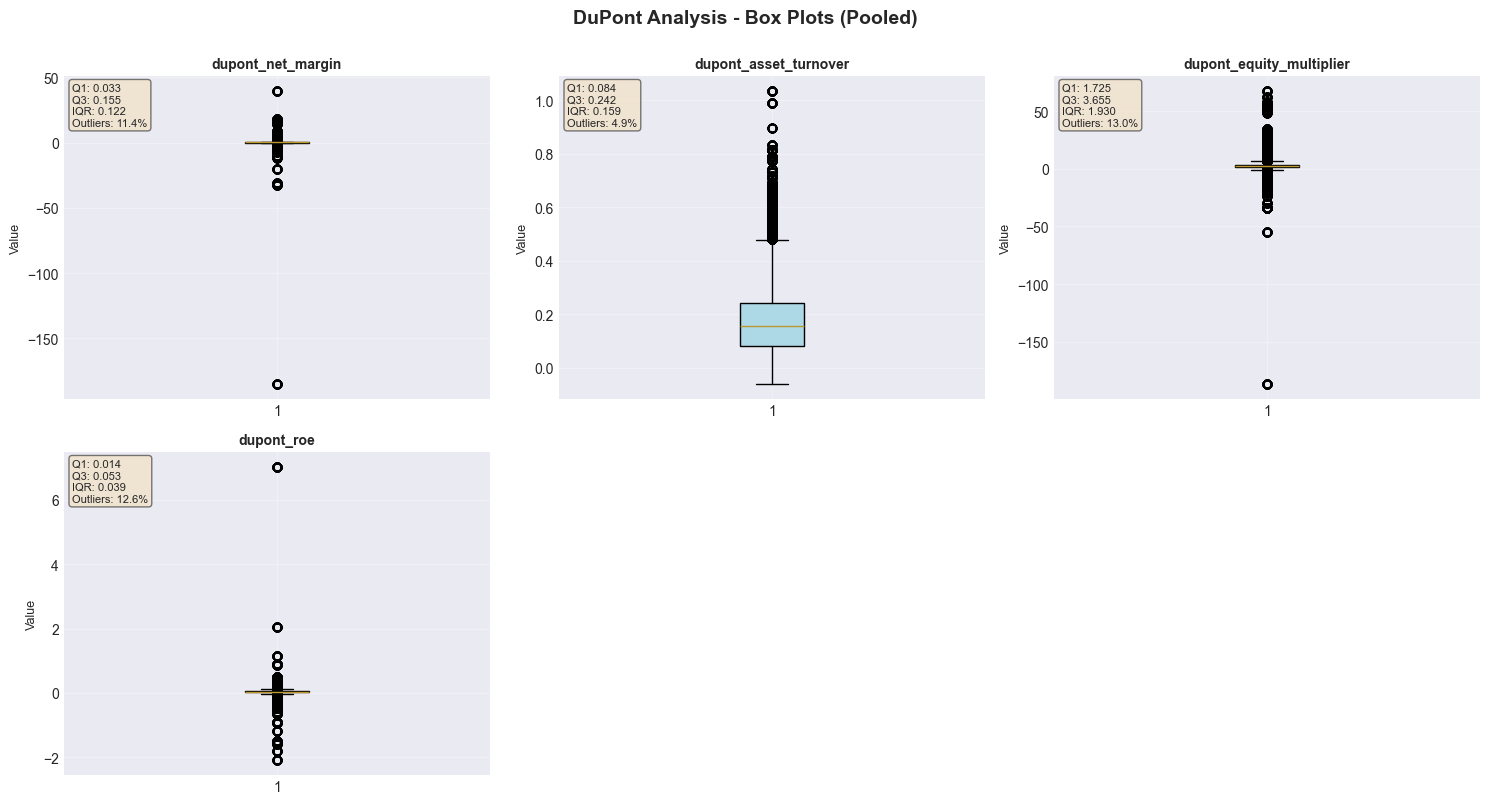


ESG SCORES


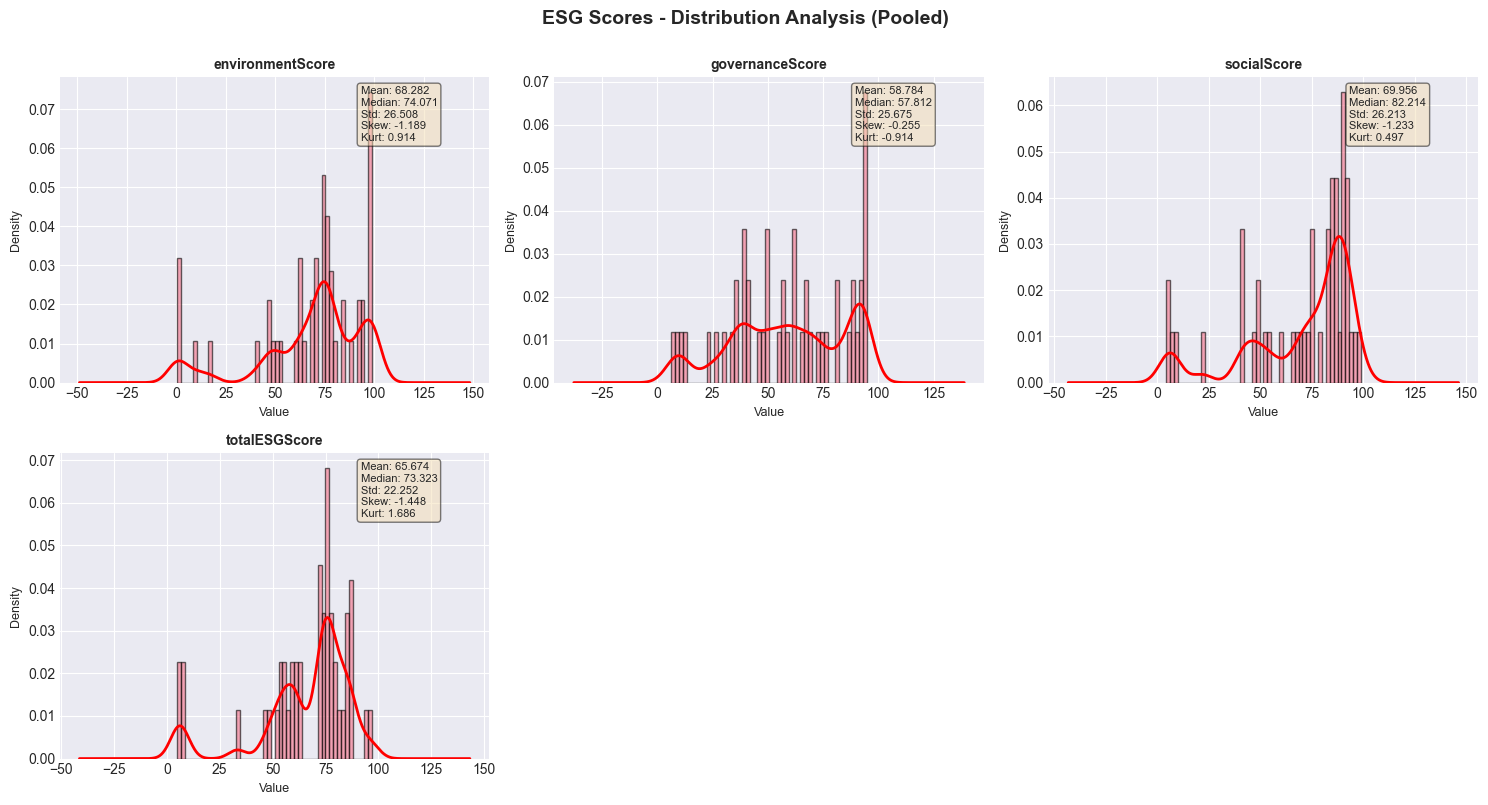

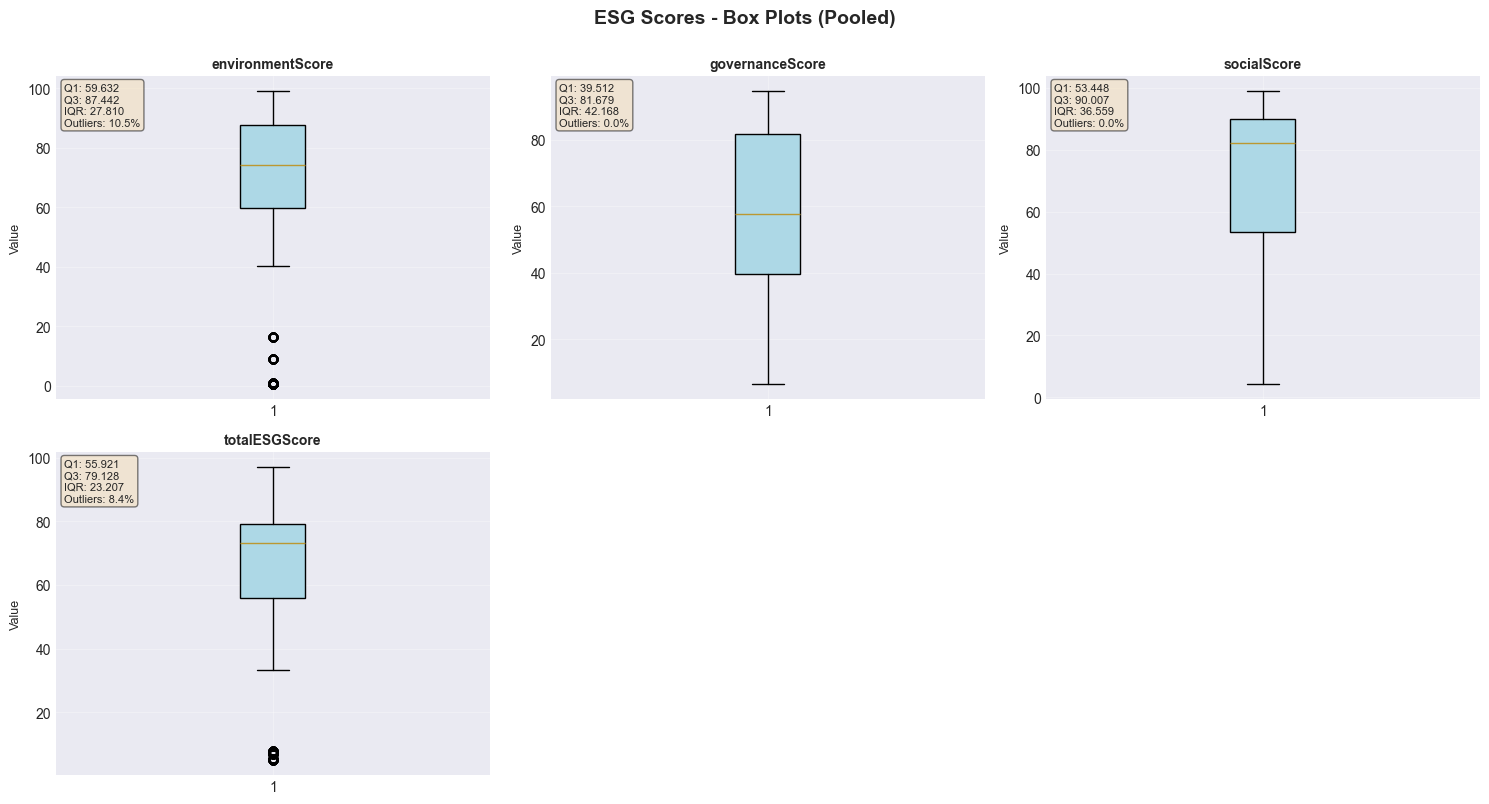


INSIDER TRADING


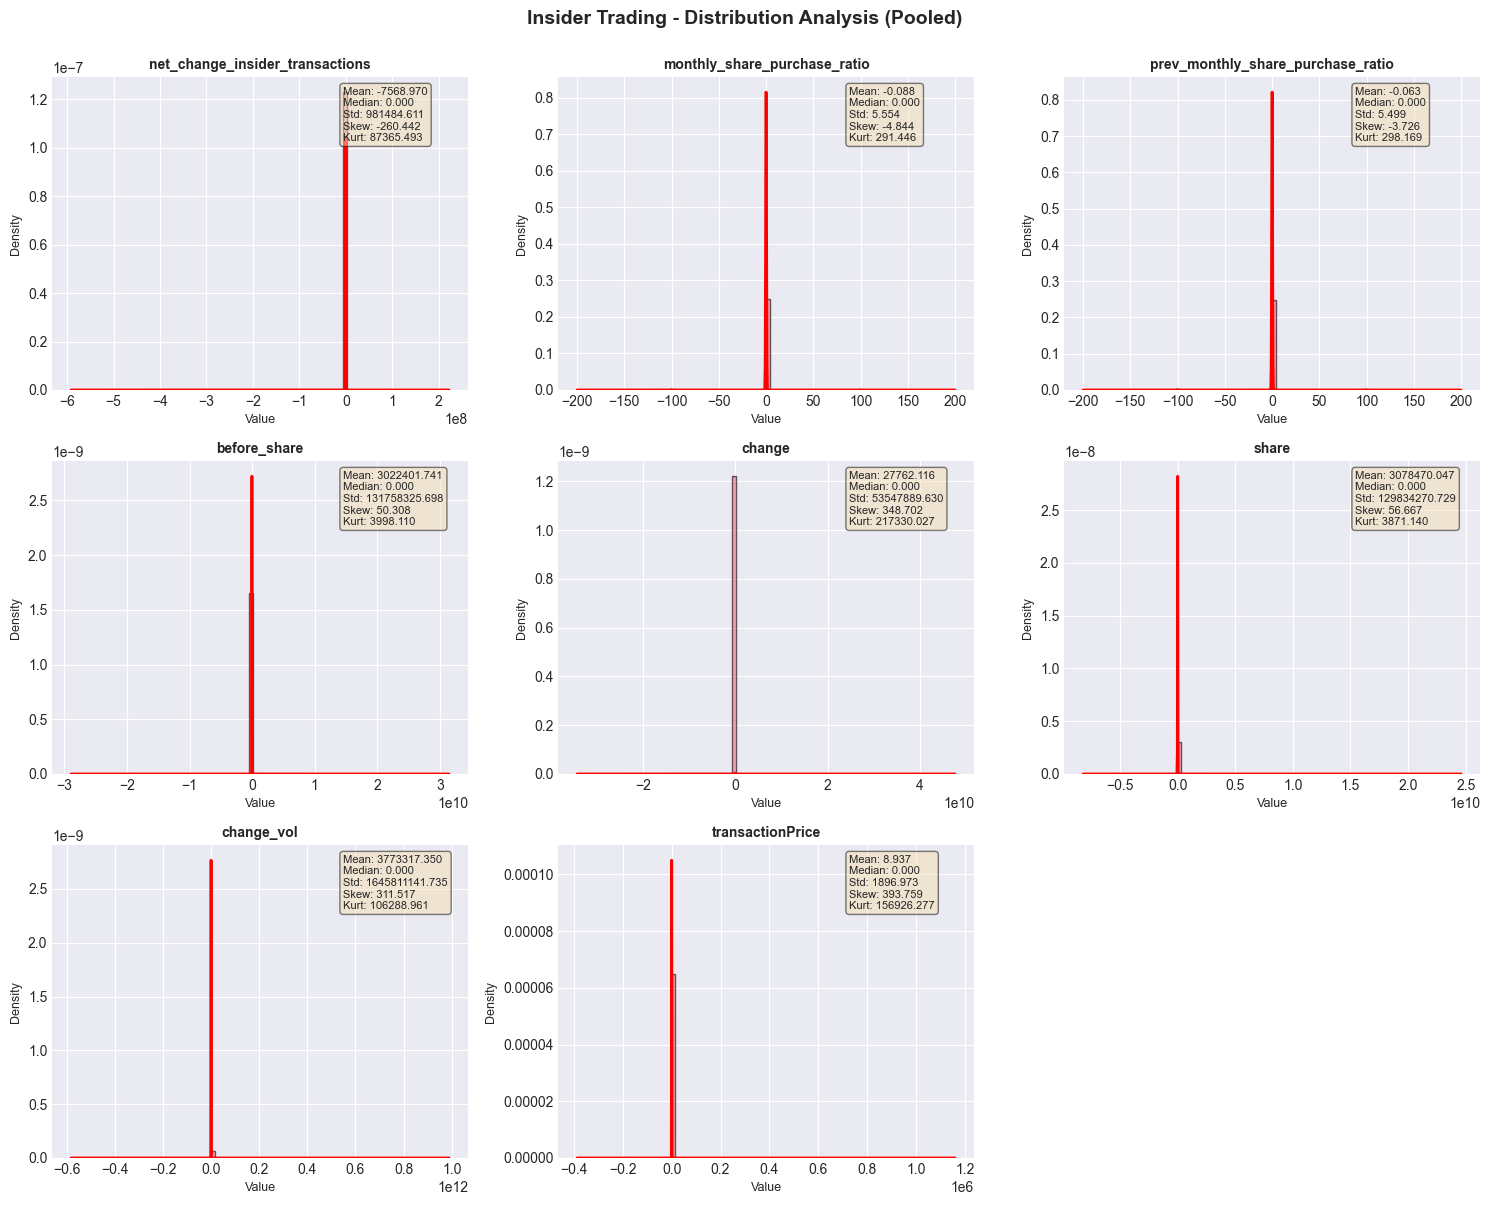

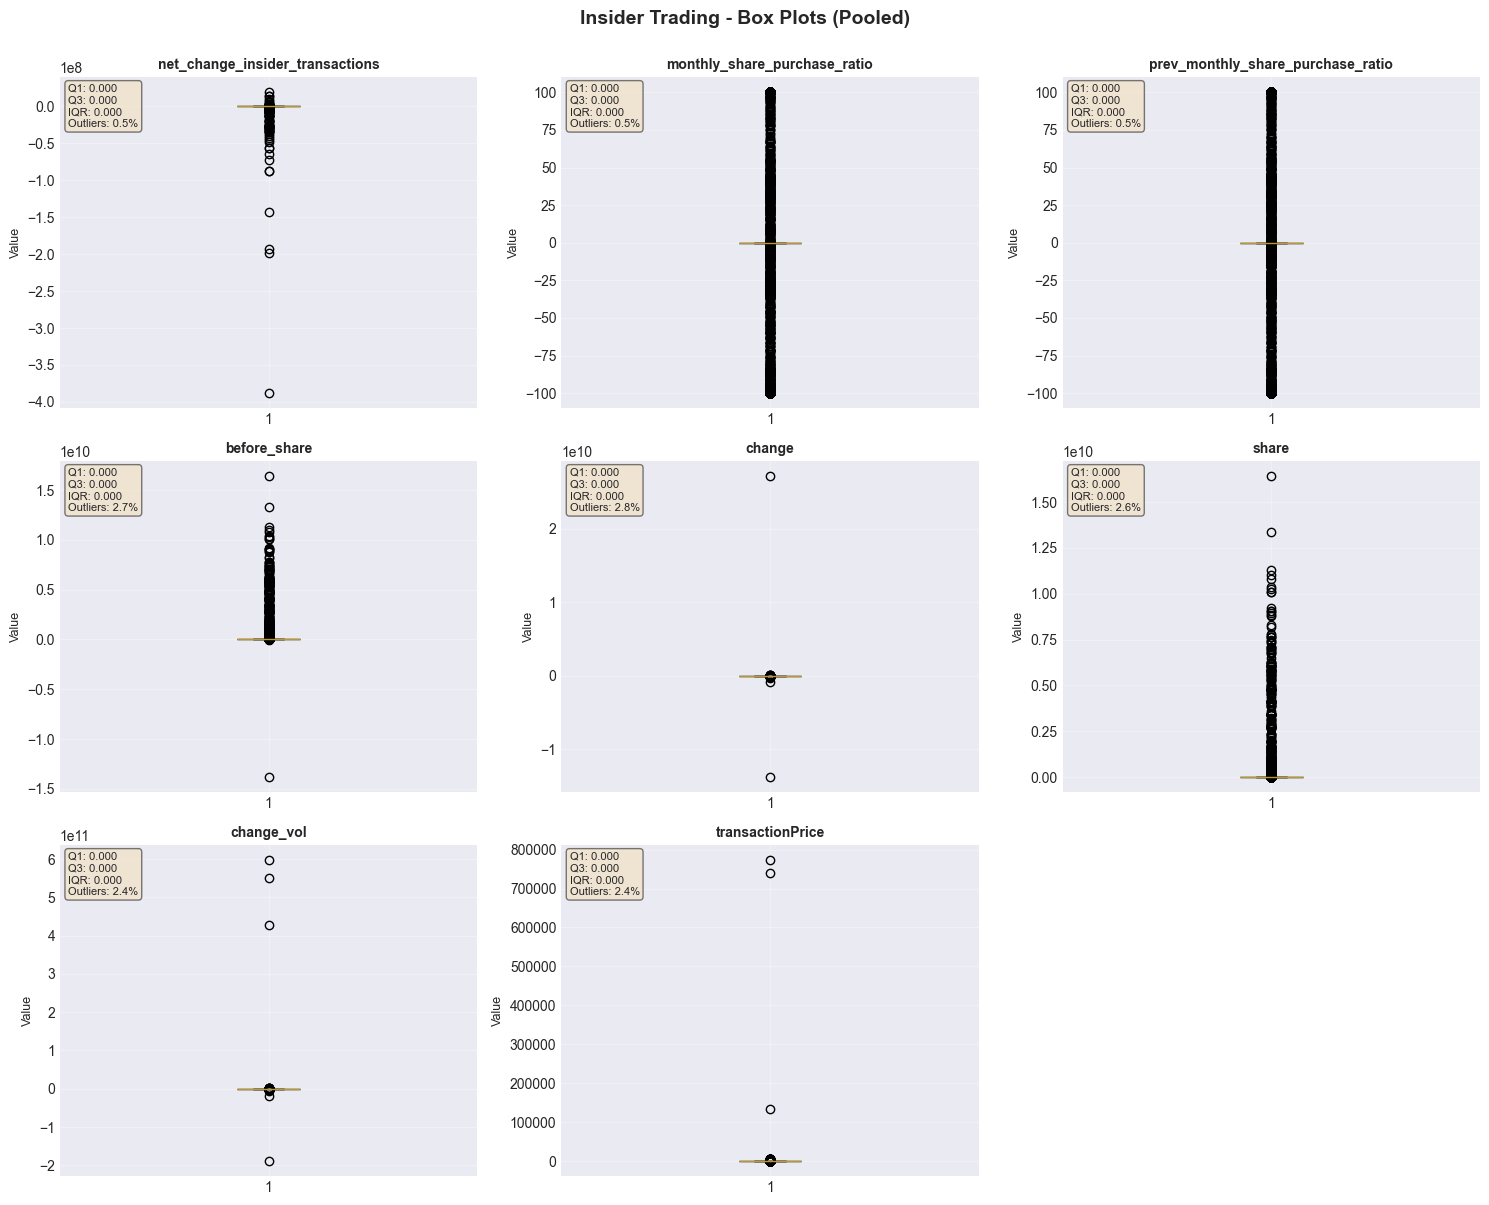


SENTIMENT


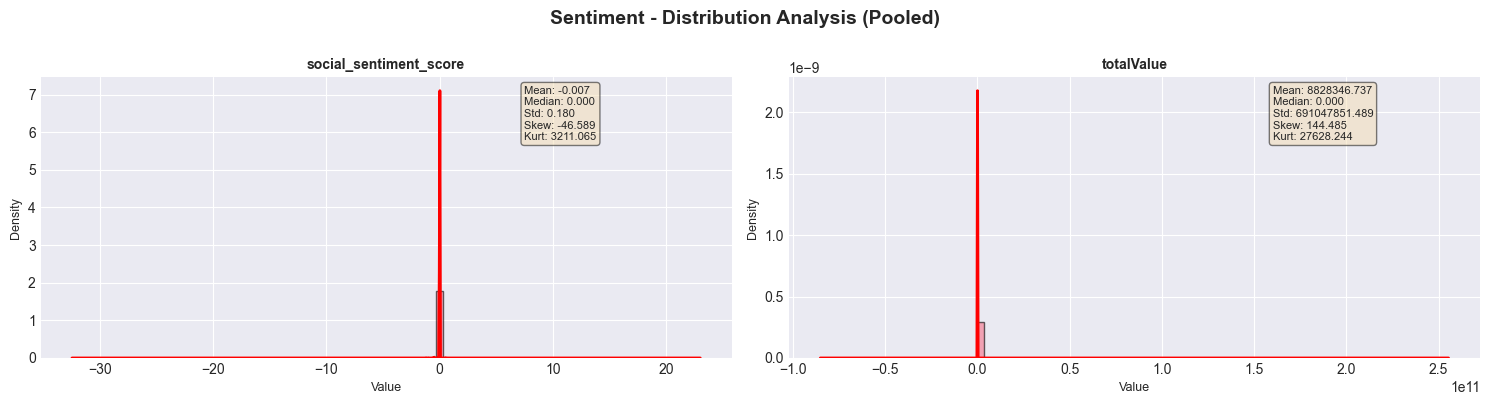

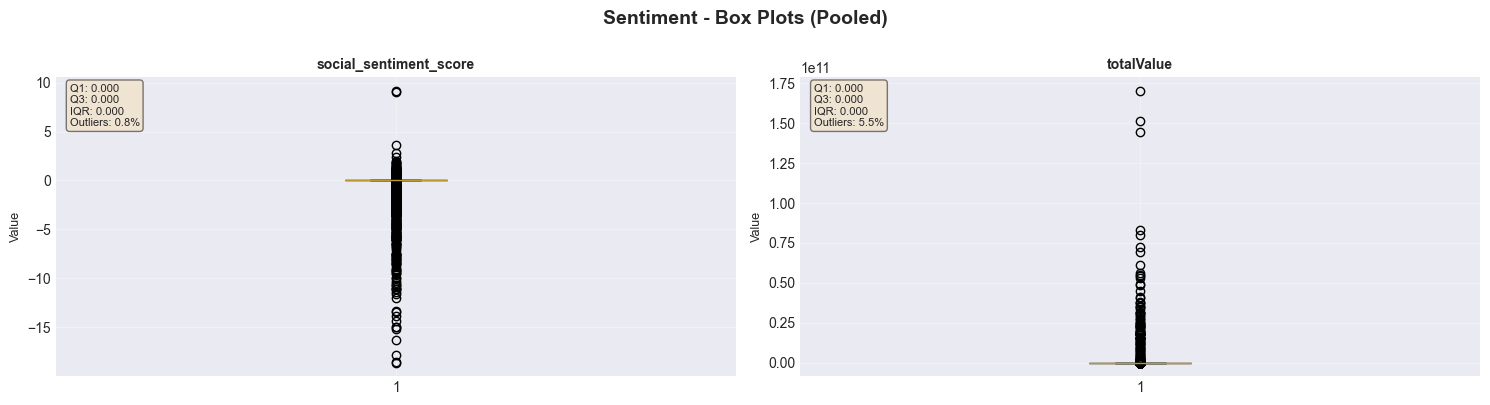

In [96]:
print("\n" + "=" * 80)
print("5. DISTRIBUTION ANALYSIS (POOLED ACROSS TICKERS)")
print("=" * 80)

def analyze_feature_distribution(data, features, category_name, is_pooled=True):
    """Analyze and visualize distribution of features"""
    
    print(f"\n{'=' * 80}")
    print(f"{category_name.upper()}")
    print(f"{'=' * 80}")
    
    valid_features = [f for f in features if f in data.columns]
    if not valid_features:
        print(f"No valid features found for {category_name}")
        return
    
    n_features = len(valid_features)
    n_cols = min(3, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols
    
    # Distribution plots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    if n_features == 1:
        axes = np.array([axes])
    elif n_rows == 1:
        axes = np.array(axes)
    else:
        axes = axes.flatten()
    
    for idx, feature in enumerate(valid_features):
        ax = axes[idx]
        feature_data = data[feature].dropna()
        
        if len(feature_data) > 0:
            # Histogram with KDE
            ax.hist(feature_data[~np.isinf(feature_data)], bins=50, alpha=0.6, edgecolor='black', density=True)
            try:
                feature_data.plot(kind='kde', ax=ax, color='red', linewidth=2)
            except:
                pass
            
            # Statistics text
            stats_text = f'Mean: {feature_data.mean():.3f}\n'
            stats_text += f'Median: {feature_data.median():.3f}\n'
            stats_text += f'Std: {feature_data.std():.3f}\n'
            stats_text += f'Skew: {skew(feature_data):.3f}\n'
            stats_text += f'Kurt: {kurtosis(feature_data):.3f}'
            
            ax.text(0.70, 0.97, stats_text, transform=ax.transAxes,
                   verticalalignment='top', fontsize=8,
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            
            ax.set_title(feature, fontsize=10, fontweight='bold')
            ax.set_xlabel('Value', fontsize=9)
            ax.set_ylabel('Density', fontsize=9)
    
    # Hide empty subplots
    for idx in range(n_features, len(axes)):
        axes[idx].axis('off')
    
    suffix = ' (Pooled)' if is_pooled else ''
    plt.suptitle(f'{category_name} - Distribution Analysis{suffix}', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
    
    # Box plots for outlier detection
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    if n_features == 1:
        axes = np.array([axes])
    elif n_rows == 1:
        axes = np.array(axes)
    else:
        axes = axes.flatten()
    
    for idx, feature in enumerate(valid_features):
        ax = axes[idx]
        feature_data = data[feature].dropna()
        
        if len(feature_data) > 0:
            bp = ax.boxplot(feature_data, vert=True, patch_artist=True)
            bp['boxes'][0].set_facecolor('lightblue')
            
            # Calculate outlier statistics
            Q1 = feature_data.quantile(0.25)
            Q3 = feature_data.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = feature_data[(feature_data < lower_bound) | (feature_data > upper_bound)]
            outlier_pct = len(outliers) / len(feature_data) * 100
            
            stats_text = f'Q1: {Q1:.3f}\n'
            stats_text += f'Q3: {Q3:.3f}\n'
            stats_text += f'IQR: {IQR:.3f}\n'
            stats_text += f'Outliers: {outlier_pct:.1f}%'
            
            ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
                   verticalalignment='top', fontsize=8,
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            
            ax.set_title(feature, fontsize=10, fontweight='bold')
            ax.set_ylabel('Value', fontsize=9)
            ax.grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(n_features, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'{category_name} - Box Plots{suffix}', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

# Analyze each category (pooled)
for category_name, features in feature_categories.items():
    analyze_feature_distribution(df, features, category_name, is_pooled=True)

### 6. Cross Ticker Distribution Comparison ###


6. CROSS-TICKER DISTRIBUTION COMPARISON

--------------------------------------------------------------------------------
Feature: Close
--------------------------------------------------------------------------------


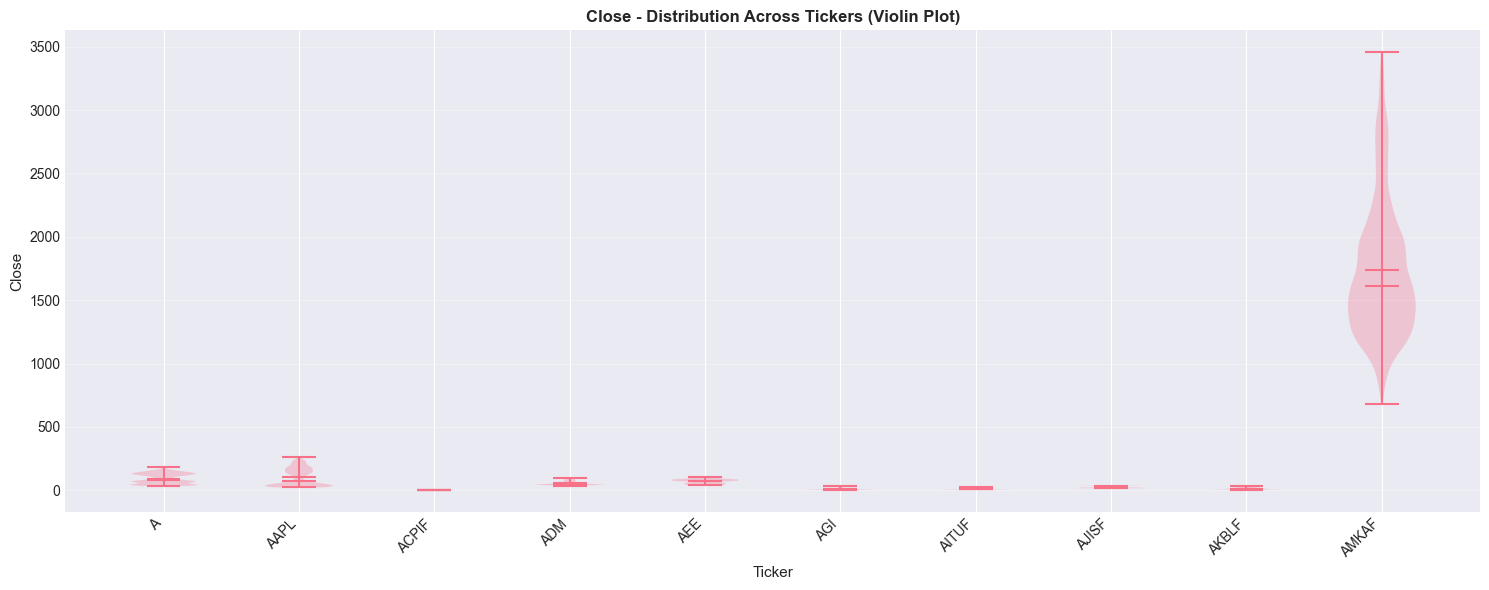


Statistics by Ticker (showing first 10):
            mean    median      std      min       max  skewness  kurtosis
Ticker                                                                    
A        92.0193   81.6200  39.8525  33.3700  179.2800    0.1351   -1.4044
AAPL    101.4032   72.2575  70.1858  22.5850  259.0200    0.4449   -1.2711
ACPIF     0.0554    0.0300   0.0427   0.0243    0.1600    1.6744    1.3794
ADM      53.8374   48.1300  15.1795  29.3100   98.2200    1.0718    0.1809
AEE      69.9581   73.7800  17.4418  37.5100  103.6700   -0.2377   -1.0891
AGI       9.2891    7.6400   5.5241   2.3400   33.1200    1.8856    3.3480
AITUF     9.6093    7.8000   5.4378   5.9300   25.1000    1.7161    1.7429
AJISF    24.8511   20.0400   7.8854  15.5000   35.5000    0.3141   -1.5679
AKBLF    12.9133   11.0750   6.3794   5.3875   30.5250    0.7513   -0.5609
AMKAF  1736.2708 1615.0000 529.0455 680.0000 3456.2000    0.9112    0.4326

---------------------------------------------------------

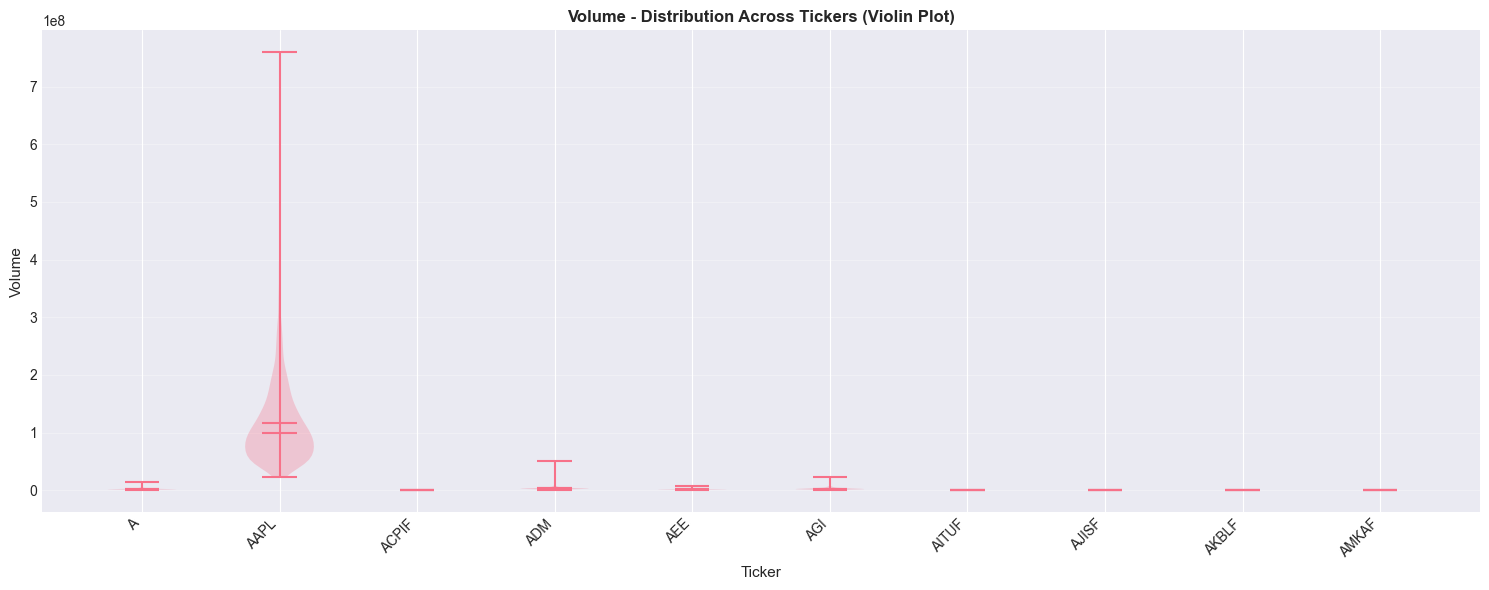


Statistics by Ticker (showing first 10):
                 mean        median           std           min            max  skewness  kurtosis
Ticker                                                                                            
A        2024096.8359  1766600.0000  1064306.7881   271900.0000  14523800.0000    2.9863   19.0421
AAPL   116960218.9896 98478800.0000 71740836.9336 23234700.0000 759385200.0000    2.0495    7.2700
ACPIF        162.0072        0.0000     3067.0541        0.0000    100000.0000   27.2279  830.6465
ADM      3389483.6259  2967700.0000  2063747.7954   411600.0000  50983400.0000    9.5015  182.6895
AEE      1532298.7460  1396100.0000   657031.1549   345800.0000   7698200.0000    2.2771   11.4505
AGI      2553047.6173  2257900.0000  1605503.9129   121900.0000  23193400.0000    2.7367   19.5778
AITUF         43.5973        0.0000     1267.2657        0.0000     60045.0000   41.9014 1881.7458
AJISF          3.5593        0.0000       69.4640        0.0000    

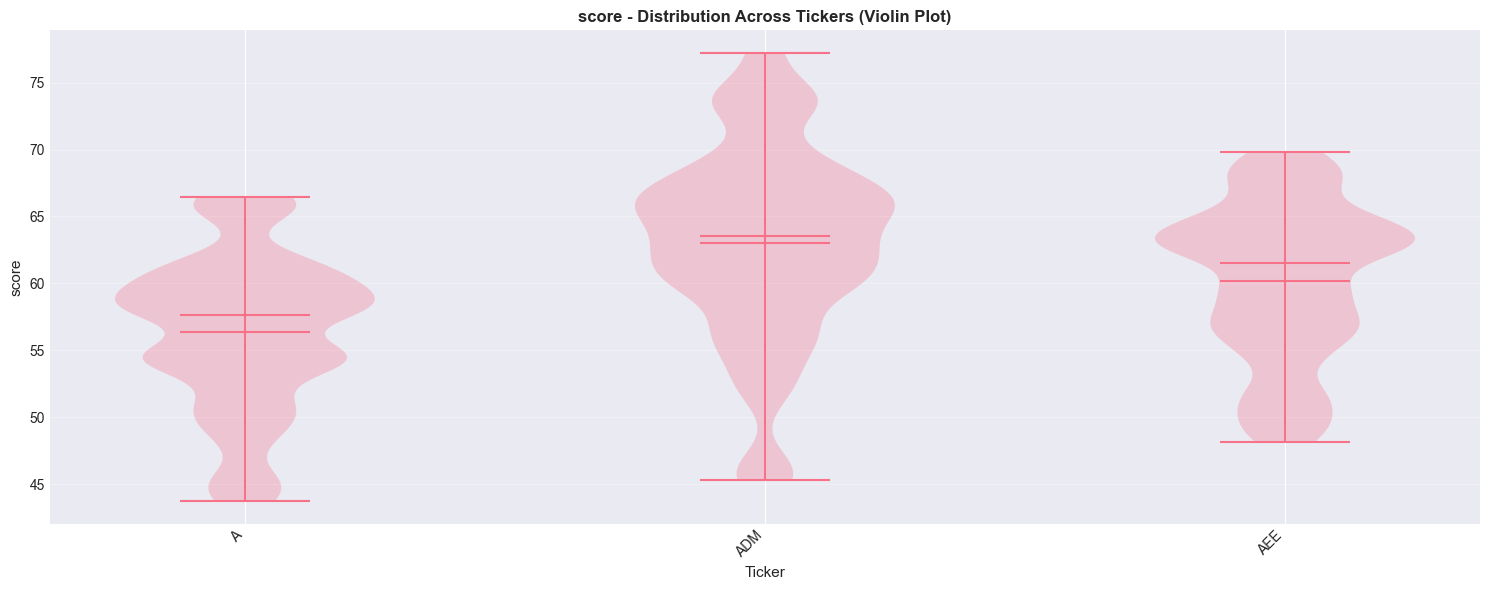


Statistics by Ticker (showing first 10):
          mean  median    std     min     max  skewness  kurtosis
Ticker                                                           
A      56.3367 57.6441 5.8443 43.7044 66.4834   -0.3251   -0.4055
AAPL       NaN     NaN    NaN     NaN     NaN       NaN       NaN
ACPIF      NaN     NaN    NaN     NaN     NaN       NaN       NaN
ADM    63.0400 63.5613 7.3260 45.2724 77.2295   -0.4397    0.0963
AEE    60.1906 61.5445 5.9018 48.1759 69.7947   -0.3901   -0.7824
AGI        NaN     NaN    NaN     NaN     NaN       NaN       NaN
AITUF      NaN     NaN    NaN     NaN     NaN       NaN       NaN
AJISF      NaN     NaN    NaN     NaN     NaN       NaN       NaN
AKBLF      NaN     NaN    NaN     NaN     NaN       NaN       NaN
AMKAF      NaN     NaN    NaN     NaN     NaN       NaN       NaN

--------------------------------------------------------------------------------
Feature: net_margin
----------------------------------------------------------------

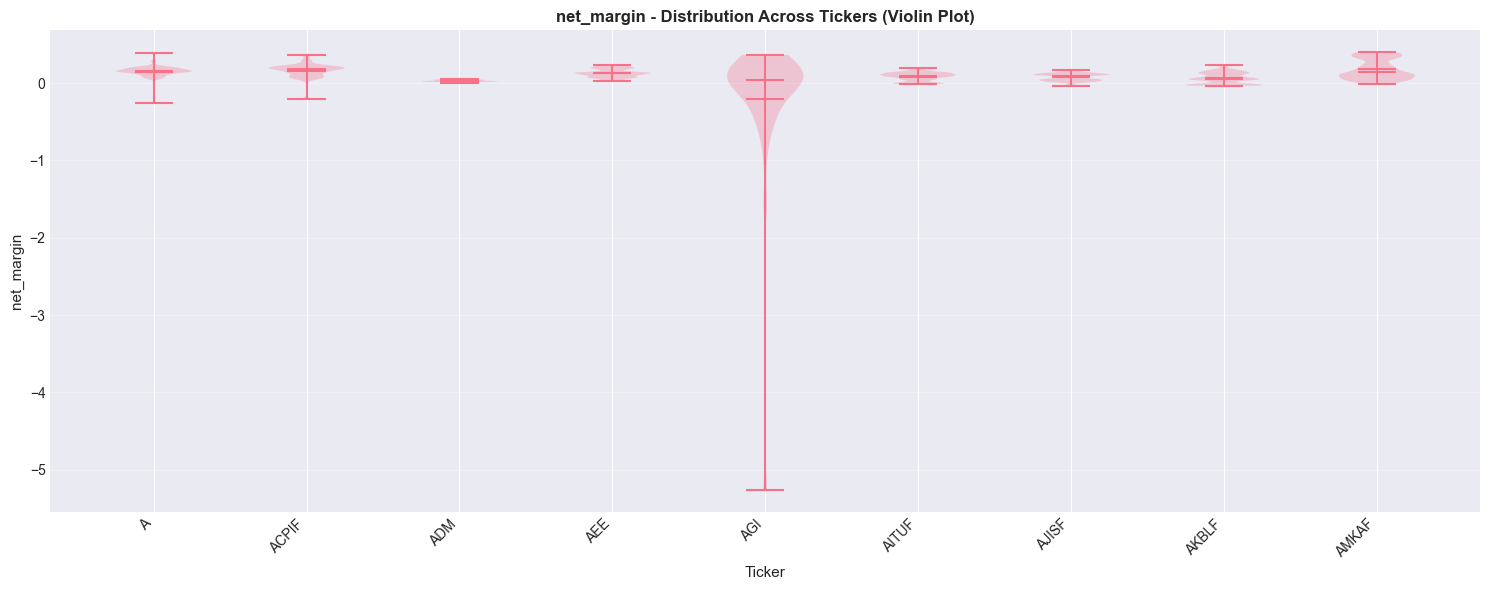


Statistics by Ticker (showing first 10):
          mean  median    std     min    max  skewness  kurtosis
Ticker                                                          
A       0.1491  0.1507 0.0920 -0.2642 0.3925   -1.9821   10.0435
AAPL       NaN     NaN    NaN     NaN    NaN       NaN       NaN
ACPIF   0.1593  0.1852 0.1069 -0.2099 0.3654   -1.3782    4.0354
ADM     0.0277  0.0261 0.0112  0.0009 0.0486   -0.0521   -0.5604
AEE     0.1295  0.1256 0.0565  0.0222 0.2347    0.1231   -0.8704
AGI    -0.2126  0.0335 0.9681 -5.2635 0.3638   -4.3389   19.5478
AITUF   0.0836  0.0876 0.0543 -0.0114 0.1927   -0.2492   -0.8187
AJISF   0.0737  0.0860 0.0494 -0.0388 0.1629   -0.2072   -0.8964
AKBLF   0.0654  0.0581 0.0759 -0.0328 0.2326    0.3633   -0.7925
AMKAF   0.1801  0.1429 0.1298 -0.0074 0.3969    0.3776   -1.2377

--------------------------------------------------------------------------------
Feature: totalESGScore
-------------------------------------------------------------------------

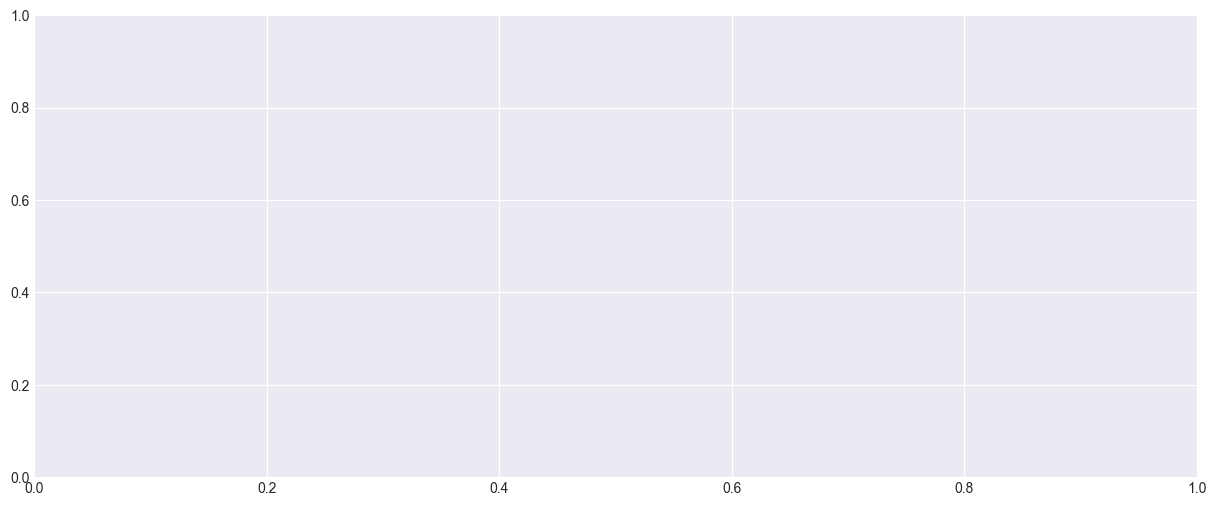

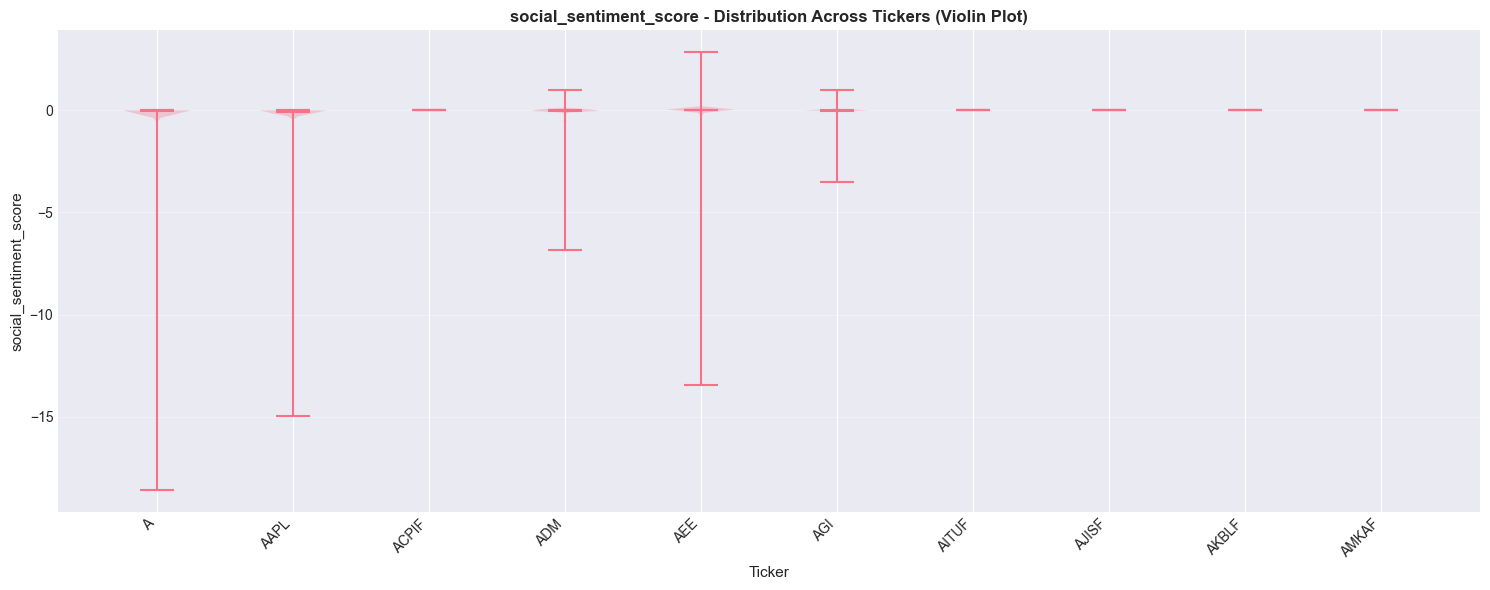


Statistics by Ticker (showing first 10):
          mean  median    std      min    max  skewness  kurtosis
Ticker                                                           
A      -0.0533  0.0000 0.8631 -18.5948 0.0000  -18.0881  341.4648
AAPL   -0.0604  0.0000 0.7451 -14.9760 0.0000  -13.4977  193.3277
ACPIF   0.0000  0.0000 0.0000   0.0000 0.0000       NaN       NaN
ADM    -0.0382  0.0000 0.2439  -6.8464 1.0000  -12.0853  252.5666
AEE    -0.0060  0.0000 0.2691 -13.4553 2.8358  -44.6479 2242.6012
AGI    -0.0148  0.0000 0.1404  -3.5000 1.0000  -10.2035  183.3976
AITUF   0.0000  0.0000 0.0000   0.0000 0.0000       NaN       NaN
AJISF   0.0000  0.0000 0.0000   0.0000 0.0000       NaN       NaN
AKBLF   0.0000  0.0000 0.0000   0.0000 0.0000       NaN       NaN
AMKAF   0.0000  0.0000 0.0000   0.0000 0.0000       NaN       NaN


In [97]:
print("\n" + "=" * 80)
print("6. CROSS-TICKER DISTRIBUTION COMPARISON")
print("=" * 80)

# Select key features for cross-ticker comparison
key_features_compare = ['Close', 'Volume', 'score', 'net_margin', 
                        'totalESGScore', 'social_sentiment_score']
key_features_compare = [f for f in key_features_compare if f in df.columns]

# Sample tickers for visualization (max 10)
sample_tickers = df['Ticker'].unique()[:10]

for feature in key_features_compare:
    print(f"\n{'-' * 80}")
    print(f"Feature: {feature}")
    print(f"{'-' * 80}")
    
    # Violin plot across tickers
    fig, ax = plt.subplots(figsize=(15, 6))
    
    ticker_data = []
    ticker_labels = []
    for ticker in sample_tickers:
        data = df[df['Ticker'] == ticker][feature].dropna()
        if len(data) > 0:
            ticker_data.append(data)
            ticker_labels.append(ticker)
    
    if ticker_data:
        parts = ax.violinplot(ticker_data, positions=range(len(ticker_labels)), 
                              showmeans=True, showmedians=True)
        
        ax.set_xticks(range(len(ticker_labels)))
        ax.set_xticklabels(ticker_labels, rotation=45, ha='right')
        ax.set_ylabel(feature, fontsize=11)
        ax.set_xlabel('Ticker', fontsize=11)
        ax.set_title(f'{feature} - Distribution Across Tickers (Violin Plot)', 
                    fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
    
    # Statistical comparison across tickers
    ticker_stats = df.groupby('Ticker')[feature].agg([
        'mean', 'median', 'std', 'min', 'max',
        ('skewness', lambda x: skew(x.dropna())),
        ('kurtosis', lambda x: kurtosis(x.dropna()))
    ])
    
    print(f"\nStatistics by Ticker (showing first 10):")
    print(ticker_stats.head(10).to_string())

### 7. Within Ticker vs Cross Ticker Variance ###


7. WITHIN-TICKER VS CROSS-TICKER VARIANCE DECOMPOSITION

Variance Decomposition (first 15 features):
                        Feature                                Total_Variance                             Within_Ticker_Var                          Between_Ticker_Var  Within_Ticker_%  Between_Ticker_%
                           Open                                   131981.0507                                    14937.6468                                 118066.1601          11.3180           89.4569
                           High                                   132576.0759                                    15038.1022                                 118565.0649          11.3430           89.4317
                            Low                                   131317.4696                                    14826.4909                                 117508.8931          11.2906           89.4846
                          Close                                   131895.7836         

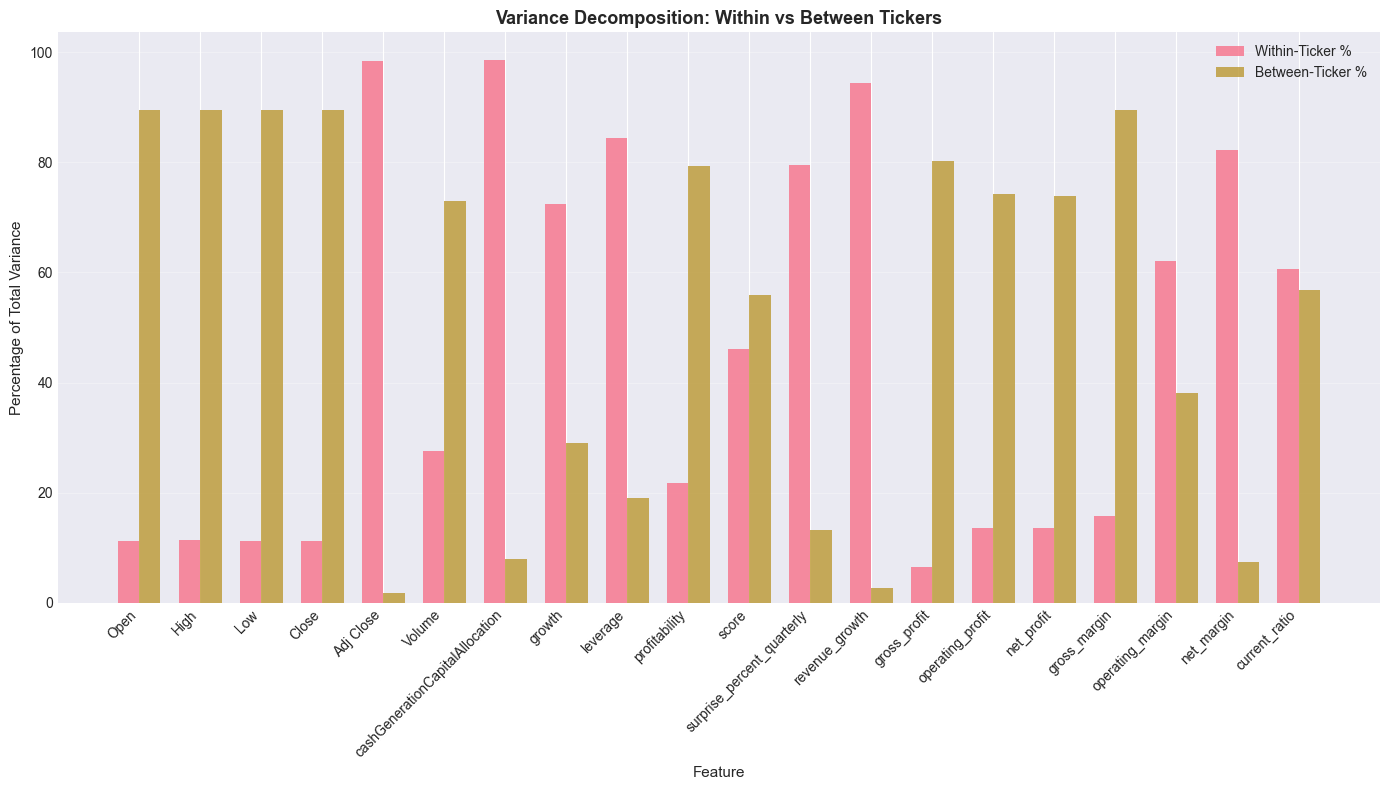


Interpretation:
  • High Within-Ticker %: Feature varies mostly over time within same ticker
  • High Between-Ticker %: Feature differs significantly between tickers


In [98]:
print("\n" + "=" * 80)
print("7. WITHIN-TICKER VS CROSS-TICKER VARIANCE DECOMPOSITION")
print("=" * 80)

variance_decomp = []

for col in numeric_cols:
    # Overall variance
    total_var = df[col].var()
    
    # Within-ticker variance (average variance within each ticker)
    within_var = df.groupby('Ticker')[col].var().mean()
    
    # Between-ticker variance (variance of ticker means)
    between_var = df.groupby('Ticker')[col].mean().var()
    
    # Calculate percentages
    if total_var > 0:
        within_pct = (within_var / total_var) * 100
        between_pct = (between_var / total_var) * 100
    else:
        within_pct = 0
        between_pct = 0
    
    variance_decomp.append({
        'Feature': col,
        'Total_Variance': total_var,
        'Within_Ticker_Var': within_var,
        'Between_Ticker_Var': between_var,
        'Within_Ticker_%': within_pct,
        'Between_Ticker_%': between_pct
    })

var_decomp_df = pd.DataFrame(variance_decomp)
print("\nVariance Decomposition (first 15 features):")
print(var_decomp_df.head(15).to_string(index=False))

# Visualize variance decomposition
fig, ax = plt.subplots(figsize=(14, 8))
features_to_plot = var_decomp_df.head(20)['Feature'].tolist()
within_pcts = var_decomp_df.head(20)['Within_Ticker_%'].tolist()
between_pcts = var_decomp_df.head(20)['Between_Ticker_%'].tolist()

x = np.arange(len(features_to_plot))
width = 0.35

bars1 = ax.bar(x - width/2, within_pcts, width, label='Within-Ticker %', alpha=0.8)
bars2 = ax.bar(x + width/2, between_pcts, width, label='Between-Ticker %', alpha=0.8)

ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Percentage of Total Variance', fontsize=11)
ax.set_title('Variance Decomposition: Within vs Between Tickers', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(features_to_plot, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  • High Within-Ticker %: Feature varies mostly over time within same ticker")
print("  • High Between-Ticker %: Feature differs significantly between tickers")

### 8. Correlation Analysis Pooled and by Ticker ###


8. CORRELATION ANALYSIS

--------------------------------------------------------------------------------
POOLED CORRELATION (All Tickers)
--------------------------------------------------------------------------------


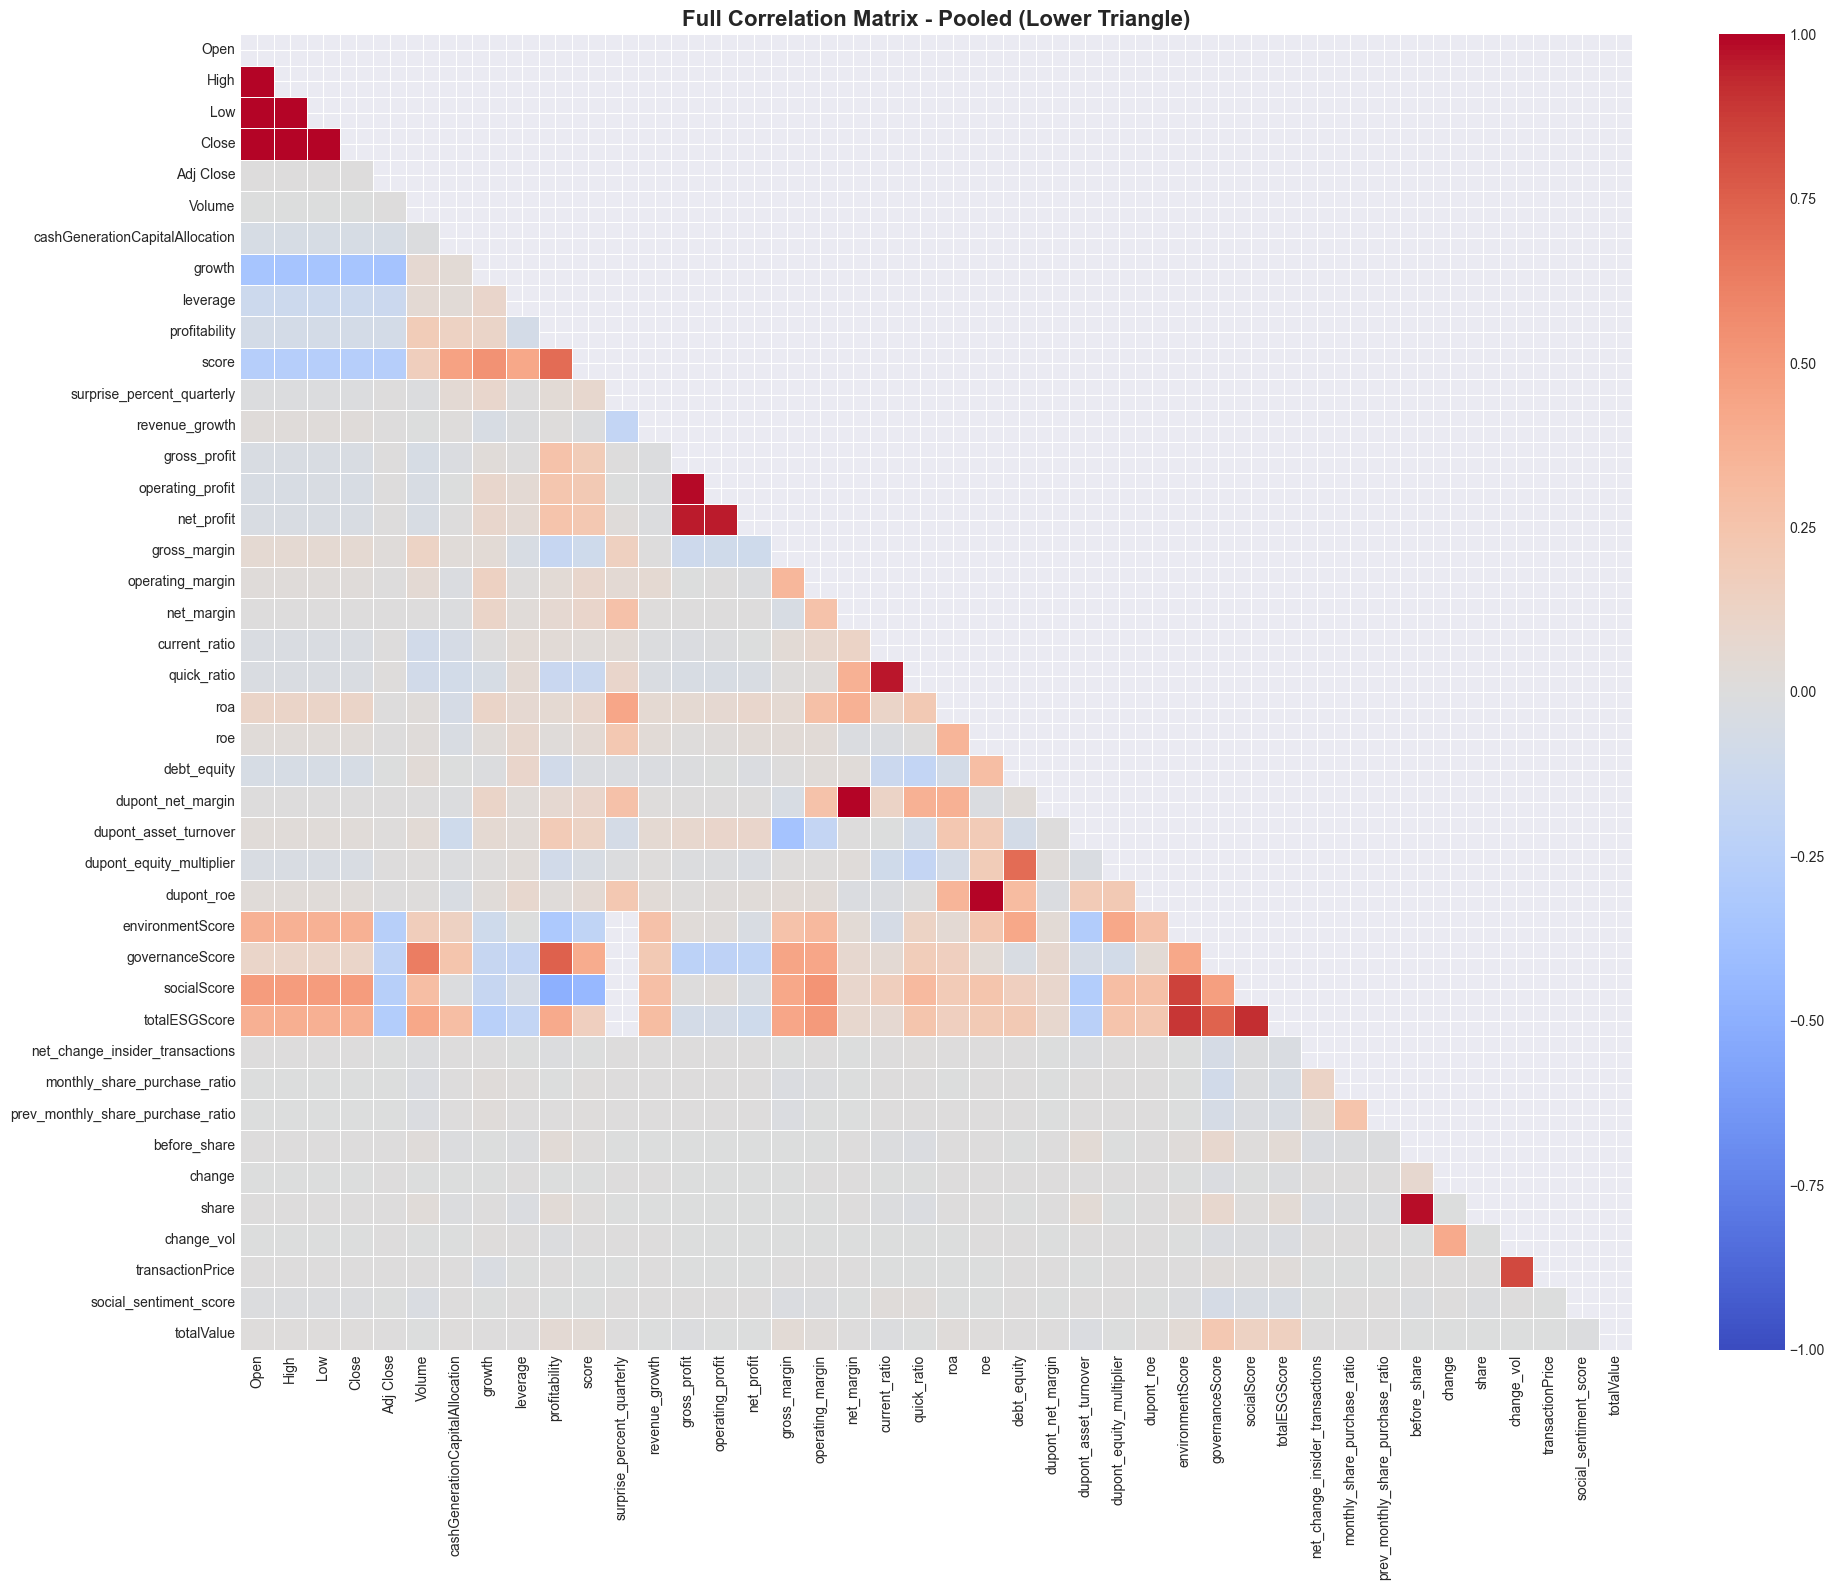


Highly Correlated Feature Pairs (|r| > 0.7):
       Feature 1         Feature 2  Correlation
      net_margin dupont_net_margin       1.0000
             roe        dupont_roe       1.0000
             Low             Close       1.0000
            Open              High       1.0000
            Open               Low       1.0000
            High             Close       1.0000
            Open             Close       0.9999
            High               Low       0.9999
    gross_profit  operating_profit       0.9855
    before_share             share       0.9828
   current_ratio       quick_ratio       0.9674
    gross_profit        net_profit       0.9609
operating_profit        net_profit       0.9607
     socialScore     totalESGScore       0.9158
environmentScore     totalESGScore       0.8973
environmentScore       socialScore       0.8590
      change_vol  transactionPrice       0.8337
   profitability   governanceScore       0.7440
 governanceScore     totalESGScore       0

In [99]:
print("\n" + "=" * 80)
print("8. CORRELATION ANALYSIS")
print("=" * 80)

# Overall correlation heatmap (pooled)
print("\n" + "-" * 80)
print("POOLED CORRELATION (All Tickers)")
print("-" * 80)

numeric_data = df[numeric_cols]
correlation_matrix = numeric_data.corr()

# Plot full correlation matrix
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Full Correlation Matrix - Pooled (Lower Triangle)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# High correlation pairs
print("\nHighly Correlated Feature Pairs (|r| > 0.7):")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', 
                                                              key=abs, 
                                                              ascending=False)
    print(high_corr_df.to_string(index=False))
else:
    print("No feature pairs with |correlation| > 0.7 found")

# Average correlation by ticker
print("\n" + "-" * 80)
print("CORRELATION STABILITY ACROSS TICKERS")
print("-" * 80)

# Calculate correlation for each ticker and analyze stability
sample_tickers_corr = df['Ticker'].unique()[:5]  # Sample 5 tickers
correlation_stability = {}

for feature_pair in high_corr_pairs[:10]:  # Top 10 pairs
    f1 = feature_pair['Feature 1']
    f2 = feature_pair['Feature 2']
    pair_name = f"{f1} vs {f2}"
    
    ticker_corrs = []
    for ticker in sample_tickers_corr:
        ticker_df = df[df['Ticker'] == ticker][[f1, f2]].dropna()
        if len(ticker_df) > 10:
            corr_val = ticker_df[f1].corr(ticker_df[f2])
            ticker_corrs.append(corr_val)
    
    if ticker_corrs:
        correlation_stability[pair_name] = {
            'Mean_Corr': np.mean(ticker_corrs),
            'Std_Corr': np.std(ticker_corrs),
            'Min_Corr': np.min(ticker_corrs),
            'Max_Corr': np.max(ticker_corrs)
        }

if correlation_stability:
    corr_stab_df = pd.DataFrame(correlation_stability).T
    print("\nCorrelation Stability Across Sample Tickers:")
    print(corr_stab_df.to_string())

### 9. Time Series Patterns Multiple Tickers


9. TIME SERIES PATTERNS (SAMPLE TICKERS)


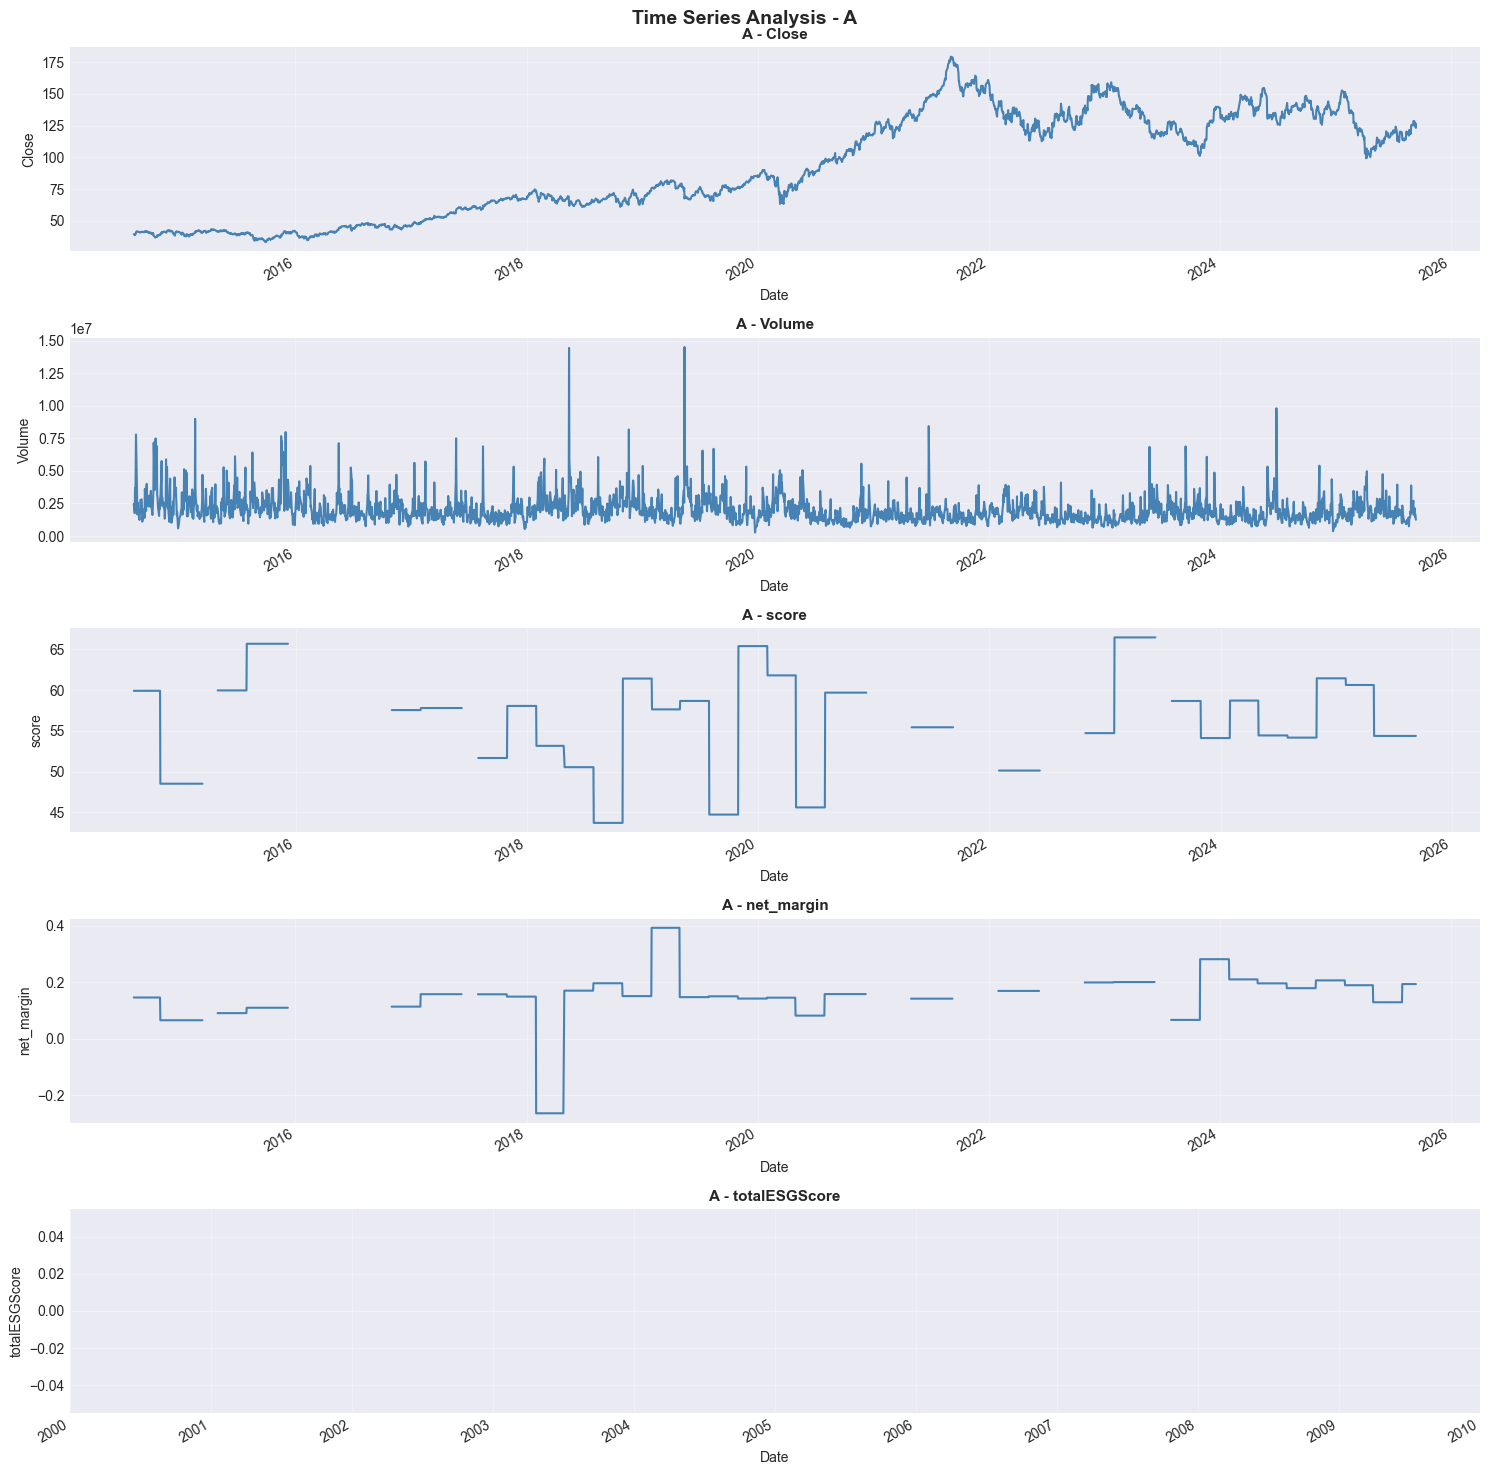

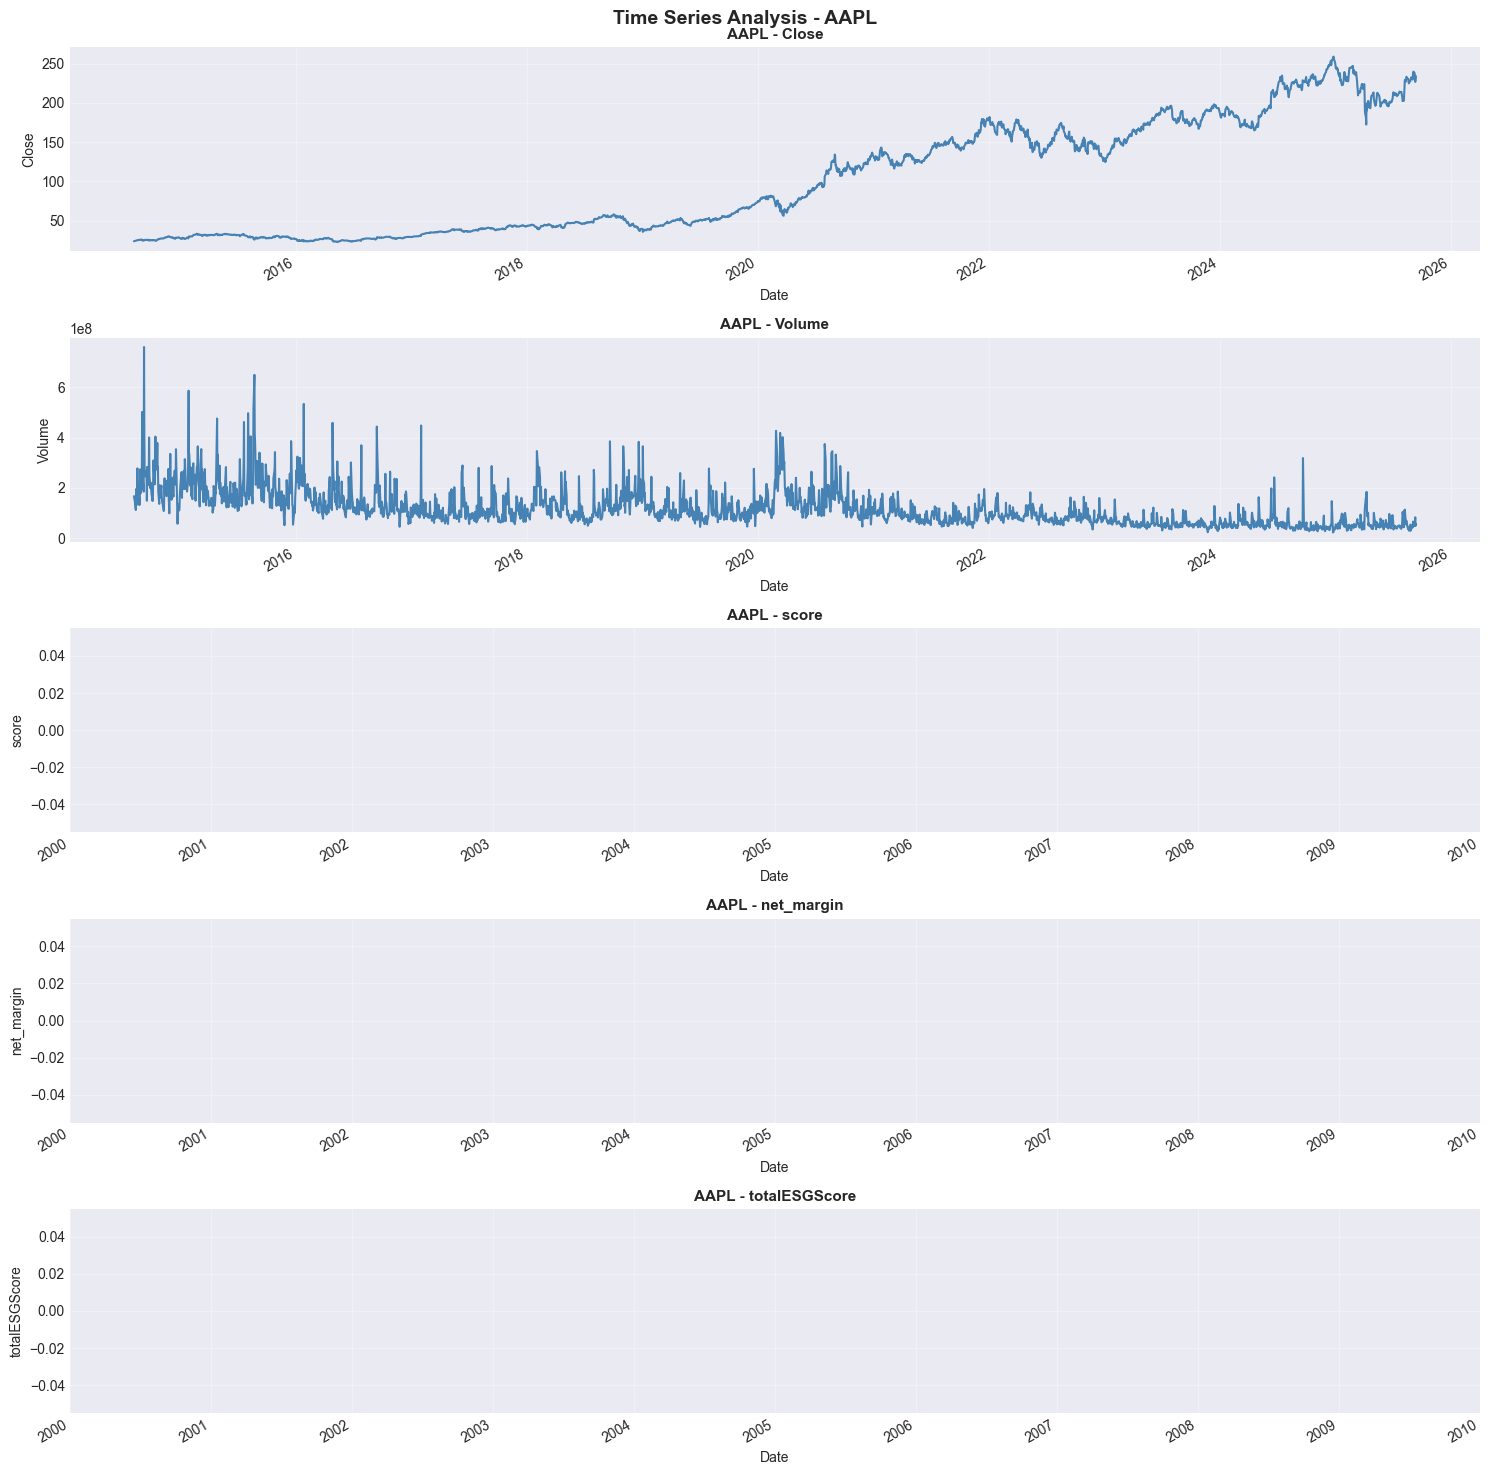

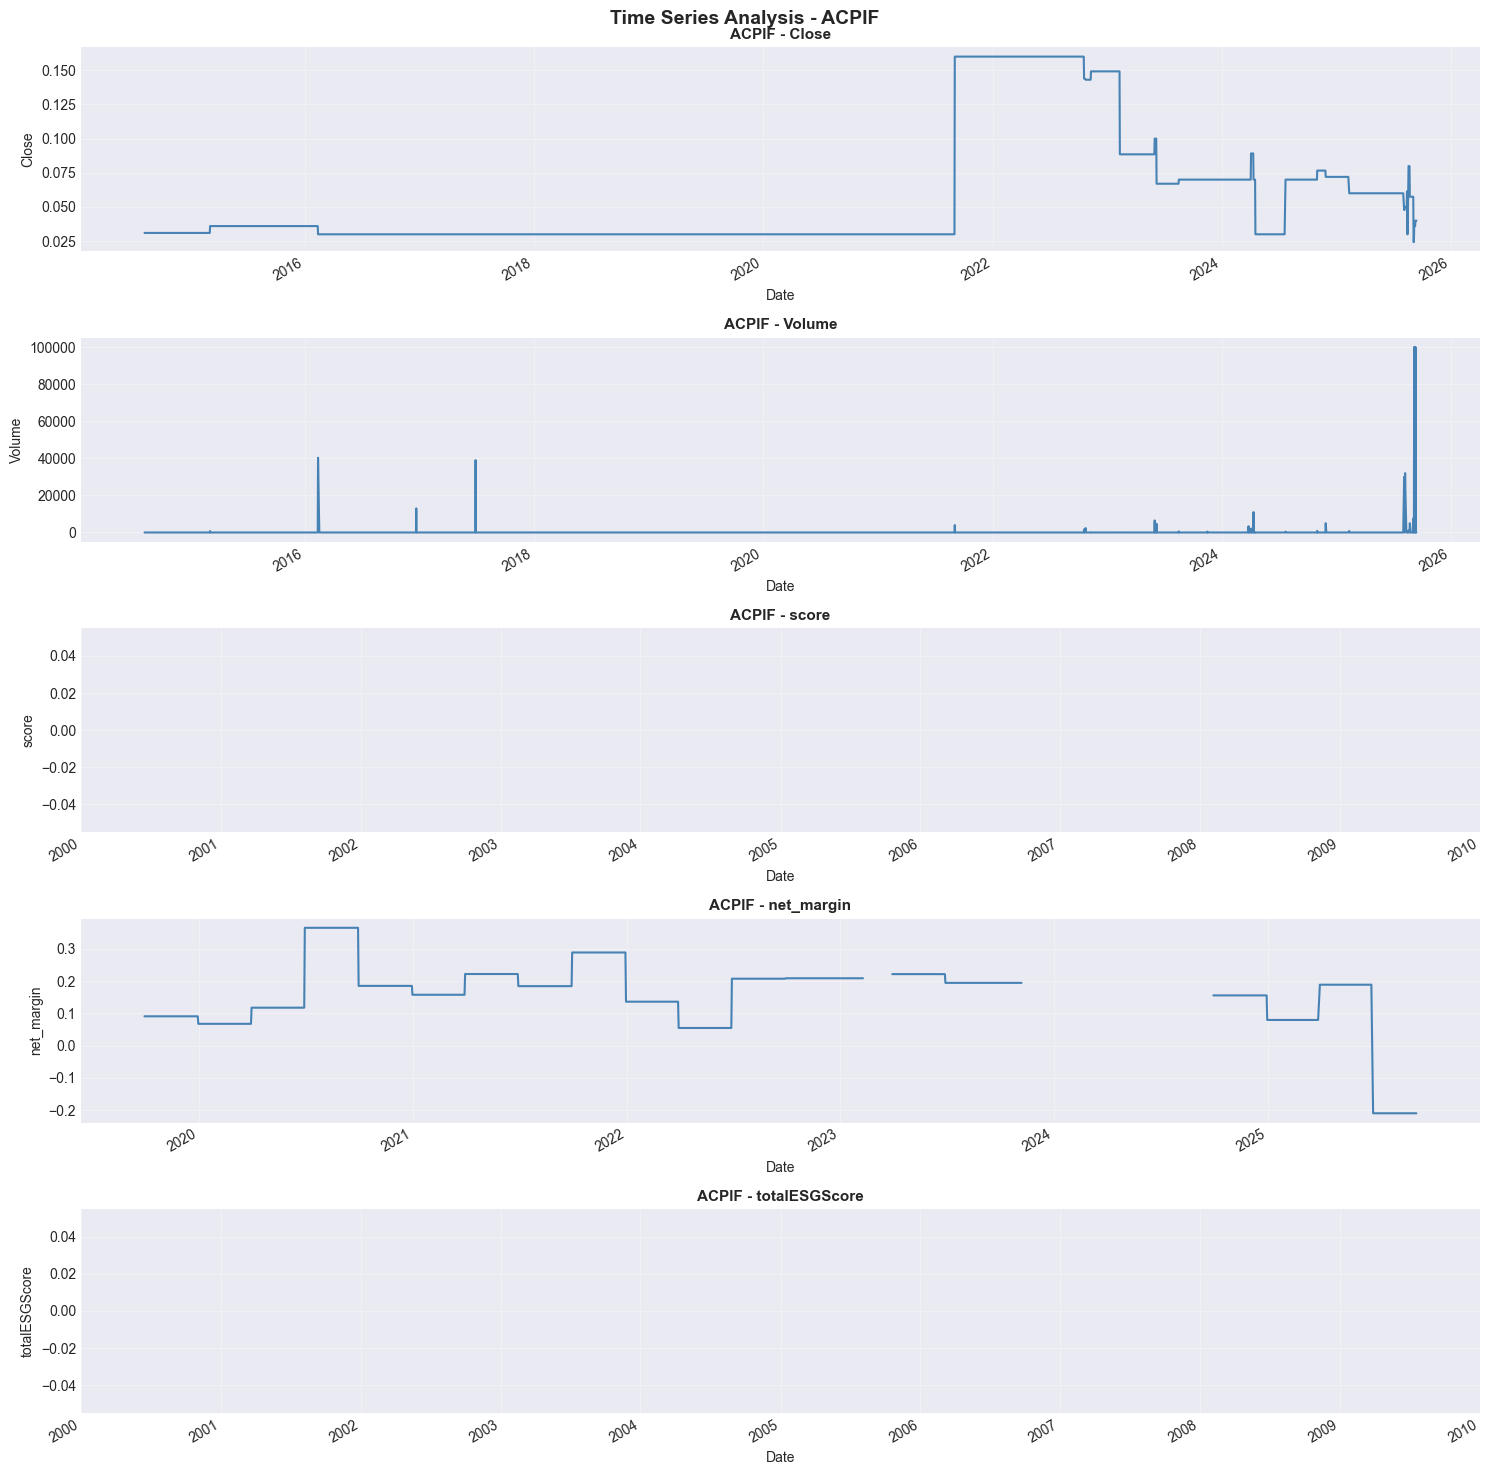

In [100]:
print("\n" + "=" * 80)
print("9. TIME SERIES PATTERNS (SAMPLE TICKERS)")
print("=" * 80)

# Select key features for time series
ts_features = ['Close', 'Volume', 'score', 'net_margin', 'totalESGScore']
ts_features = [f for f in ts_features if f in df.columns]

# Plot time series for sample tickers
sample_ts_tickers = df['Ticker'].unique()[:3]  # First 3 tickers

for ticker in sample_ts_tickers:
    ticker_data = df[df['Ticker'] == ticker].sort_values('Date')
    
    if len(ticker_data) > 10:
        fig, axes = plt.subplots(len(ts_features), 1, figsize=(15, 3*len(ts_features)))
        if len(ts_features) == 1:
            axes = [axes]
        
        for idx, feature in enumerate(ts_features):
            ax = axes[idx]
            ticker_data.plot(x='Date', y=feature, ax=ax, legend=False, color='steelblue')
            ax.set_title(f'{ticker} - {feature}', fontsize=11, fontweight='bold')
            ax.set_xlabel('Date', fontsize=10)
            ax.set_ylabel(feature, fontsize=10)
            ax.grid(True, alpha=0.3)
        
        plt.suptitle(f'Time Series Analysis - {ticker}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

### 10. Pooled Normality Tests ###

In [101]:
print("\n" + "=" * 80)
print("10. NORMALITY TESTS (POOLED)")
print("=" * 80)

normality_results = []

for col in numeric_cols:
    data = df[col].dropna()
    if len(data) > 8:
        statistic, p_value = normaltest(data)
        normality_results.append({
            'Feature': col,
            'Test Statistic': statistic,
            'P-Value': p_value,
            'Normal Distribution': 'Yes' if p_value > 0.05 else 'No'
        })

normality_df = pd.DataFrame(normality_results).sort_values('P-Value', ascending=False)
print("\nNormality Test Results (D'Agostino-Pearson) - Pooled Data:")
print("H0: Data follows normal distribution (reject if p-value < 0.05)")
print(normality_df.head(15).to_string(index=False))


10. NORMALITY TESTS (POOLED)

Normality Test Results (D'Agostino-Pearson) - Pooled Data:
H0: Data follows normal distribution (reject if p-value < 0.05)
                        Feature  Test Statistic  P-Value Normal Distribution
                       leverage          4.4485   0.1081                 Yes
                governanceScore        678.0436   0.0000                  No
                    socialScore        727.7951   0.0000                  No
               environmentScore        739.3898   0.0000                  No
                          score        896.1674   0.0000                  No
                  totalESGScore       1034.3781   0.0000                  No
                           High     439013.4300   0.0000                  No
                            Low     440613.7414   0.0000                  No
                      Adj Close    1195745.2470   0.0000                  No
                           Open     439843.4040   0.0000                  No

### 11. Feature Transformation Recommendations ###

In [102]:
print("\n" + "=" * 80)
print("11. FEATURE TRANSFORMATION RECOMMENDATIONS")
print("=" * 80)

recommendations = []

for col in numeric_cols:
    data = df[col].dropna()
    if len(data) > 0:
        sk = skew(data)
        kurt = kurtosis(data)
        
        # Check variation across tickers
        ticker_means = df.groupby('Ticker')[col].mean()
        cv_tickers = ticker_means.std() / abs(ticker_means.mean()) if ticker_means.mean() != 0 else 0
        
        rec = {'Feature': col}
        
        # Skewness recommendation
        if abs(sk) > 1:
            rec['Skewness'] = f'{sk:.2f} (High)'
            if sk > 0:
                rec['Transform'] = 'Log/Square Root (right-skewed)'
            else:
                rec['Transform'] = 'Square/Exp (left-skewed)'
        elif abs(sk) > 0.5:
            rec['Skewness'] = f'{sk:.2f} (Moderate)'
            rec['Transform'] = 'Box-Cox/Yeo-Johnson'
        else:
            rec['Skewness'] = f'{sk:.2f} (Low)'
            rec['Transform'] = 'No transformation'
        
        # Outliers
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        outlier_pct = len(data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]) / len(data) * 100
        
        rec['Outliers%'] = f'{outlier_pct:.1f}'
        rec['Ticker_CV'] = f'{cv_tickers:.2f}'
        
        recommendations.append(rec)

rec_df = pd.DataFrame(recommendations)
print("\nTransformation Recommendations (first 15 features):")
print(rec_df.head(15).to_string(index=False))



11. FEATURE TRANSFORMATION RECOMMENDATIONS

Transformation Recommendations (first 15 features):
                        Feature        Skewness                      Transform Outliers% Ticker_CV
                           Open     8.06 (High) Log/Square Root (right-skewed)      11.3      3.50
                           High     8.03 (High) Log/Square Root (right-skewed)      11.4      3.49
                            Low     8.08 (High) Log/Square Root (right-skewed)      11.3      3.51
                          Close     8.05 (High) Log/Square Root (right-skewed)      11.3      3.50
                      Adj Close   -80.51 (High)       Square/Exp (left-skewed)      15.1     10.77
                         Volume    14.65 (High) Log/Square Root (right-skewed)      16.6      4.74
cashGenerationCapitalAllocation     -0.05 (Low)              No transformation       3.9      0.08
                         growth    -1.92 (High)       Square/Exp (left-skewed)       6.8      0.11
            

### 12. Scaling Recommendations ###

In [103]:
print("\n" + "=" * 80)
print("12. SCALING RECOMMENDATIONS (MULTI-TICKER AWARE)")
print("=" * 80)

scaling_rec = []

for col in numeric_cols:
    data = df[col].dropna()
    if len(data) > 0:
        # Overall statistics
        range_val = data.max() - data.min()
        mean_val = data.mean()
        std_val = data.std()
        sk = skew(data)
        
        # Ticker-level statistics
        ticker_ranges = df.groupby('Ticker')[col].apply(lambda x: x.max() - x.min())
        ticker_means = df.groupby('Ticker')[col].mean()
        
        # Determine scaling method
        if abs(sk) > 1:
            scaling_method = 'RobustScaler (high skewness)'
        elif ticker_means.std() / abs(ticker_means.mean()) > 1 if ticker_means.mean() != 0 else False:
            scaling_method = 'StandardScaler per ticker (high cross-ticker variance)'
        elif (data.min() >= 0) and (data.max() <= 1):
            scaling_method = 'Already normalized [0,1]'
        elif range_val > 1000:
            scaling_method = 'StandardScaler or MinMaxScaler'
        else:
            scaling_method = 'StandardScaler'
        
        scaling_rec.append({
            'Feature': col,
            'Overall_Range': f'{data.min():.2f} to {data.max():.2f}',
            'Mean_Ticker_Range': f'{ticker_ranges.mean():.2f}',
            'Cross_Ticker_CV': f'{ticker_means.std() / abs(ticker_means.mean()):.2f}' if ticker_means.mean() != 0 else 'inf',
            'Recommended_Scaler': scaling_method
        })

scaling_df = pd.DataFrame(scaling_rec)
print("\nScaling Recommendations (first 15 features):")
print(scaling_df.head(15).to_string(index=False))

print("\nScaling Strategy Notes:")
print("  • Features with high cross-ticker CV may benefit from per-ticker standardization")
print("  • Consider whether to scale before or after train-test split")
print("  • For time series, use fit on training period only")


12. SCALING RECOMMENDATIONS (MULTI-TICKER AWARE)

Scaling Recommendations (first 15 features):
                        Feature                                         Overall_Range       Mean_Ticker_Range Cross_Ticker_CV                                     Recommended_Scaler
                           Open                                       0.00 to 5337.00                  144.53            3.50                           RobustScaler (high skewness)
                           High                                       0.00 to 5337.00                  145.16            3.49                           RobustScaler (high skewness)
                            Low                                       0.00 to 5337.00                  143.87            3.51                           RobustScaler (high skewness)
                          Close                                       0.00 to 5337.00                  144.55            3.50                           RobustScaler (high skewness)

### 13. Zero/Constant Value Analysis by Ticker ###

In [104]:
print("\n" + "=" * 80)
print("13. ZERO AND CONSTANT VALUE ANALYSIS")
print("=" * 80)

zero_analysis = []

for col in numeric_cols:
    data = df[col].dropna()
    if len(data) > 0:
        # Overall zero percentage
        zero_count = (data == 0).sum()
        zero_pct = zero_count / len(data) * 100
        n_unique = data.nunique()
        
        # Per-ticker analysis
        tickers_with_all_zeros = 0
        for ticker in df['Ticker'].unique():
            ticker_data = df[df['Ticker'] == ticker][col].dropna()
            if len(ticker_data) > 0 and (ticker_data == 0).all():
                tickers_with_all_zeros += 1
        
        if zero_pct > 50 or n_unique < 5 or tickers_with_all_zeros > 0:
            zero_analysis.append({
                'Feature': col,
                'Zero_Count': zero_count,
                'Zero_%': f'{zero_pct:.2f}',
                'Unique_Values': n_unique,
                'Tickers_All_Zeros': tickers_with_all_zeros,
                'Action': 'Drop' if zero_pct > 90 or tickers_with_all_zeros > df['Ticker'].nunique() * 0.5 else 'Review'
            })

if zero_analysis:
    zero_df = pd.DataFrame(zero_analysis)
    print("\nFeatures with High Zero Percentage or Low Variance:")
    print(zero_df.to_string(index=False))
else:
    print("\nNo features with concerning zero percentages or low variance detected.")


13. ZERO AND CONSTANT VALUE ANALYSIS

Features with High Zero Percentage or Low Variance:
                          Feature  Zero_Count Zero_%  Unique_Values  Tickers_All_Zeros Action
                           Volume      173311  53.53          61429                  0 Review
  net_change_insider_transactions      322173  99.51           1467                 85   Drop
     monthly_share_purchase_ratio      322173  99.51            848                 85   Drop
prev_monthly_share_purchase_ratio      322178  99.51            849                 85   Drop
                     before_share      315141  97.34           8443                 80   Drop
                           change      314690  97.20           6110                 71   Drop
                            share      315190  97.35           8383                 80   Drop
                       change_vol      316014  97.61           7707                 71   Drop
                 transactionPrice      315987  97.60           

### 14. Feature Importance Basic Metrics ###


14. FEATURE QUALITY INDICATORS

Feature Quality Ranking (Top 20):
                 Feature  Completeness_%  Ticker_Coverage_%  Zero_%  Unique_Ratio      CV  Within_Var_%  Quality_Score
               Adj Close        100.0000           100.0000  0.0000        0.4051 81.7468       98.3139        88.1017
                    High        100.0000           100.0000  0.0000        0.1334  3.6896       11.3430        82.6674
                   Close        100.0000           100.0000  0.0000        0.1318  3.7005       11.3164        82.6358
                     Low        100.0000           100.0000  0.0000        0.1314  3.7126       11.2906        82.6275
                    Open        100.0000           100.0000  0.0000        0.1312  3.7013       11.3180        82.6249
                  Volume        100.0000           100.0000 53.5314        0.1897  5.5497       27.6269        73.0885
dupont_equity_multiplier         63.7221            96.5517  0.0000        0.0146  1.8233       57.7

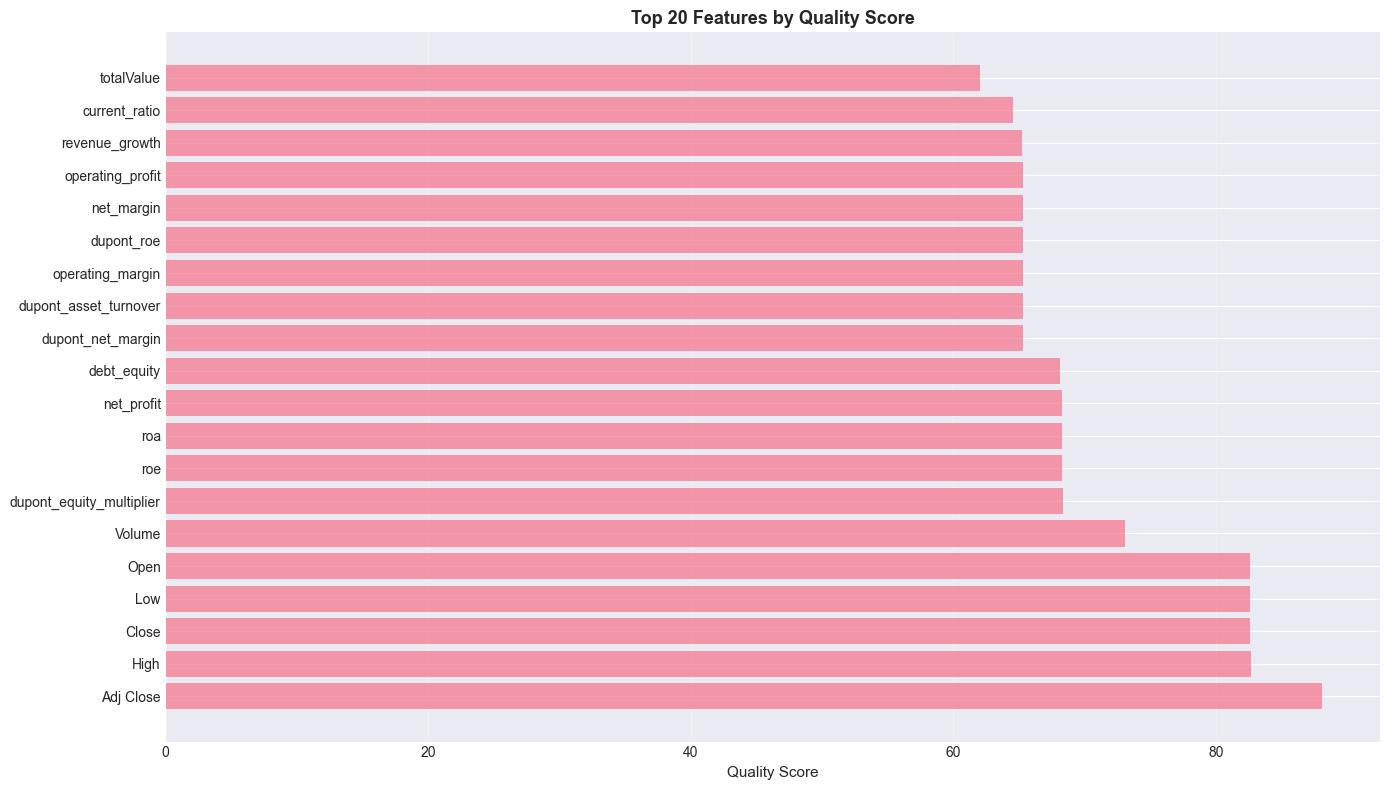

In [105]:
print("\n" + "=" * 80)
print("14. FEATURE QUALITY INDICATORS")
print("=" * 80)

feature_quality = []

for col in numeric_cols:
    data = df[col].dropna()
    if len(data) > 0:
        # Calculate various quality metrics
        completeness = (len(data) / len(df)) * 100
        zero_pct = ((data == 0).sum() / len(data)) * 100
        unique_ratio = data.nunique() / len(data)
        cv = data.std() / abs(data.mean()) if data.mean() != 0 else np.inf
        
        # Ticker coverage
        tickers_with_data = df[df[col].notna()]['Ticker'].nunique()
        ticker_coverage = (tickers_with_data / df['Ticker'].nunique()) * 100
        
        # Variance decomposition
        within_var = df.groupby('Ticker')[col].var().mean()
        total_var = data.var()
        within_pct = (within_var / total_var * 100) if total_var > 0 else 0
        
        # Quality score (higher is better)
        quality_score = (
            completeness * 0.3 +  # Completeness weight
            ticker_coverage * 0.3 +  # Ticker coverage weight
            min(100, (1 - zero_pct/100) * 100) * 0.2 +  # Non-zero weight
            min(100, unique_ratio * 100) * 0.2  # Uniqueness weight
        )
        
        feature_quality.append({
            'Feature': col,
            'Completeness_%': completeness,
            'Ticker_Coverage_%': ticker_coverage,
            'Zero_%': zero_pct,
            'Unique_Ratio': unique_ratio,
            'CV': cv if not np.isinf(cv) else 999,
            'Within_Var_%': within_pct,
            'Quality_Score': quality_score
        })

quality_df = pd.DataFrame(feature_quality).sort_values('Quality_Score', ascending=False)
quality_df = quality_df.replace([np.inf, -np.inf], 999)

print("\nFeature Quality Ranking (Top 20):")
print(quality_df.head(20).to_string(index=False))

print("\nFeature Quality Ranking (Bottom 10 - May need attention):")
print(quality_df.tail(10).to_string(index=False))

# Visualize feature quality
fig, ax = plt.subplots(figsize=(14, 8))
top_features = quality_df.head(20)
ax.barh(range(len(top_features)), top_features['Quality_Score'], alpha=0.7)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'])
ax.set_xlabel('Quality Score', fontsize=11)
ax.set_title('Top 20 Features by Quality Score', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


### 15. Ticker Specific Anomaly Detection ###

In [106]:
print("\n" + "=" * 80)
print("15. TICKER-SPECIFIC ANOMALY DETECTION")
print("=" * 80)

# Identify tickers with unusual patterns
anomalous_tickers = []

for ticker in df['Ticker'].unique():
    ticker_df = df[df['Ticker'] == ticker]
    
    # Check for various anomalies
    issues = []
    
    # Missing data
    missing_pct = ticker_df.isnull().sum().sum() / (len(ticker_df) * len(ticker_df.columns)) * 100
    if missing_pct > 50:
        issues.append(f'High missing: {missing_pct:.1f}%')
    
    # Data coverage
    if len(ticker_df) < 30:
        issues.append(f'Low coverage: {len(ticker_df)} days')
    
    # Check for constant features
    constant_features = []
    for col in numeric_cols:
        if ticker_df[col].nunique() == 1:
            constant_features.append(col)
    
    if len(constant_features) > 5:
        issues.append(f'{len(constant_features)} constant features')
    
    if issues:
        anomalous_tickers.append({
            'Ticker': ticker,
            'Num_Records': len(ticker_df),
            'Missing_%': f'{missing_pct:.1f}',
            'Issues': '; '.join(issues)
        })

if anomalous_tickers:
    anomaly_df = pd.DataFrame(anomalous_tickers).sort_values('Missing_%', ascending=False)
    print("\nTickers with Potential Data Quality Issues:")
    print(anomaly_df.head(20).to_string(index=False))
else:
    print("\nNo significant ticker-level anomalies detected.")


15. TICKER-SPECIFIC ANOMALY DETECTION

Tickers with Potential Data Quality Issues:
Ticker  Num_Records Missing_%                                    Issues
  AAPL         2791      58.9                       High missing: 58.9%
  ULTA         2791      58.9                       High missing: 58.9%
  MRVL         2791      58.9                       High missing: 58.9%
  COST         2791      58.9                       High missing: 58.9%
 CVVIF         2791      56.8 High missing: 56.8%; 10 constant features
 SVKEF         2791      53.8  High missing: 53.8%; 7 constant features
 HSNGF         2791      53.3 High missing: 53.3%; 10 constant features
 OVCHF         2791      51.9  High missing: 51.9%; 9 constant features
 SCBFF         2791      51.7  High missing: 51.7%; 7 constant features
 SPIZF         2791      50.5 High missing: 50.5%; 10 constant features
 BKFCF         2791      50.3 High missing: 50.3%; 10 constant features
 GGDVF         2791      48.5                      1

### 16. Feature Correlations with Price Movement ###


16. FEATURE CORRELATION WITH PRICE CHANGES (TARGET PROXY)

Feature Correlations with Price Movement (Top 20):
                        Feature  Corr_with_Return  Corr_with_Direction  Abs_Corr
               environmentScore            0.0183               0.3111    0.0183
                    socialScore            0.0153               0.2951    0.0153
     surprise_percent_quarterly            0.0152              -0.0120    0.0152
                  totalESGScore            0.0148               0.3247    0.0148
                     dupont_roe           -0.0083              -0.0075    0.0083
                            roe           -0.0083              -0.0070    0.0083
                    debt_equity           -0.0073               0.0435    0.0073
       dupont_equity_multiplier           -0.0071               0.0344    0.0071
                         growth           -0.0066               0.0028    0.0066
                          score           -0.0058               0.0108    0.005

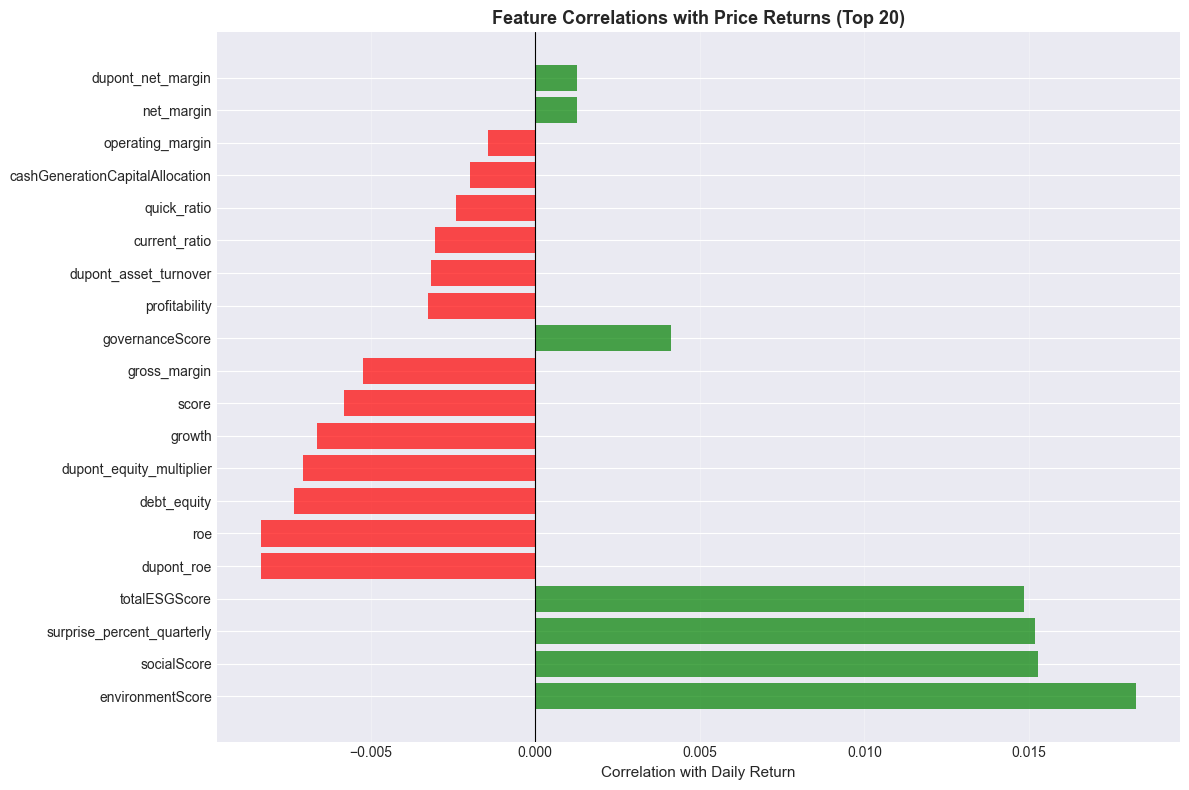

In [107]:
print("\n" + "=" * 80)
print("16. FEATURE CORRELATION WITH PRICE CHANGES (TARGET PROXY)")
print("=" * 80)

# Calculate daily returns
df_sorted = df.sort_values(['Ticker', 'Date'])
df_sorted['Daily_Return'] = df_sorted.groupby('Ticker')['Close'].pct_change()
df_sorted['Price_Direction'] = (df_sorted['Daily_Return'] > 0).astype(int)

# Calculate correlations with price movement
price_correlations = []

for col in numeric_cols:
    if col not in ['Open', 'High', 'Low', 'Close', 'Adj Close']:
        corr_return = df_sorted[[col, 'Daily_Return']].corr().iloc[0, 1]
        
        # Point-biserial correlation with direction
        data_clean = df_sorted[[col, 'Price_Direction']].dropna()
        if len(data_clean) > 30:
            corr_direction = data_clean[col].corr(data_clean['Price_Direction'])
        else:
            corr_direction = np.nan
        
        price_correlations.append({
            'Feature': col,
            'Corr_with_Return': corr_return,
            'Corr_with_Direction': corr_direction,
            'Abs_Corr': abs(corr_return)
        })

price_corr_df = pd.DataFrame(price_correlations).sort_values('Abs_Corr', ascending=False)
print("\nFeature Correlations with Price Movement (Top 20):")
print(price_corr_df.head(20).to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(12, 8))
top_20 = price_corr_df.head(20)
colors = ['green' if x > 0 else 'red' for x in top_20['Corr_with_Return']]
ax.barh(range(len(top_20)), top_20['Corr_with_Return'], color=colors, alpha=0.7)
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['Feature'])
ax.set_xlabel('Correlation with Daily Return', fontsize=11)
ax.set_title('Feature Correlations with Price Returns (Top 20)', fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [108]:
print("\n" + "=" * 80)
print("17. COMPREHENSIVE SUMMARY AND RECOMMENDATIONS")
print("=" * 80)

print("\n📊 DATASET SUMMARY:")
print(f"  • Total Records: {len(df):,}")
print(f"  • Unique Tickers: {df['Ticker'].nunique()}")
print(f"  • Date Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"  • Features Analyzed: {len(numeric_cols)}")
print(f"  • Avg Records per Ticker: {len(df) / df['Ticker'].nunique():.0f}")

print("\n🔍 DATA QUALITY FINDINGS:")
if len(missing_data) > 0:
    print(f"  • Features with Missing Values: {len(missing_data)}")
    print(f"    Top missing: {missing_data.iloc[0]['Column']} ({missing_data.iloc[0]['Missing_Percent']:.1f}%)")
else:
    print(f"  • No missing values detected")

if len(zero_analysis) > 0:
    print(f"  • Features with >50% Zeros: {len([z for z in zero_analysis if float(z['Zero_%']) > 50])}")

if len(anomalous_tickers) > 0:
    print(f"  • Tickers with Data Issues: {len(anomalous_tickers)}")

print("\n📈 DISTRIBUTION CHARACTERISTICS:")
high_skew = len([r for r in recommendations if abs(float(r['Skewness'].split()[0])) > 1])
print(f"  • Highly Skewed Features (|skew| > 1): {high_skew}")
high_outliers = len([r for r in recommendations if float(r['Outliers%']) > 5])
print(f"  • Features with >5% Outliers: {high_outliers}")

print("\n🔗 CORRELATION INSIGHTS:")
print(f"  • High Correlation Pairs (|r| > 0.7): {len(high_corr_pairs)}")
if len(price_corr_df) > 0:
    top_predictor = price_corr_df.iloc[0]
    print(f"  • Strongest Price Predictor: {top_predictor['Feature']} (r={top_predictor['Corr_with_Return']:.3f})")

print("\n📊 VARIANCE DECOMPOSITION:")
high_within = len([v for v in variance_decomp if v['Within_Ticker_%'] > 70])
high_between = len([v for v in variance_decomp if v['Between_Ticker_%'] > 70])
print(f"  • Features with >70% Within-Ticker Variance: {high_within}")
print(f"  • Features with >70% Between-Ticker Variance: {high_between}")

print("\n" + "=" * 80)
print("📝 PREPROCESSING RECOMMENDATIONS")
print("=" * 80)

print("\n1. DATA CLEANING:")
print("   ✓ Handle missing values (already ffilled for quarterly data)")
if len(zero_analysis) > 0:
    drop_features = [z['Feature'] for z in zero_analysis if z['Action'] == 'Drop']
    if drop_features:
        print(f"   ✓ Consider dropping features: {', '.join(drop_features[:5])}")
if len(anomalous_tickers) > 0:
    print(f"   ✓ Review {len(anomalous_tickers)} tickers with data quality issues")

print("\n2. FEATURE TRANSFORMATION:")
log_transform = [r['Feature'] for r in recommendations if 'Log' in r['Transform']]
if log_transform:
    print(f"   ✓ Apply log transform to: {', '.join(log_transform[:5])}")
boxcox_features = [r['Feature'] for r in recommendations if 'Box-Cox' in r['Transform']]
if boxcox_features:
    print(f"   ✓ Apply Box-Cox/Yeo-Johnson to: {', '.join(boxcox_features[:5])}")

print("\n3. OUTLIER HANDLING:")
if high_outliers > 0:
    print(f"   ✓ Apply winsorization to {high_outliers} features with high outliers")
    print("   ✓ Consider 1st-99th percentile clipping")

print("\n4. SCALING STRATEGY:")
print("   ✓ Option A: Pool all data → StandardScaler/RobustScaler")
print("   ✓ Option B: Per-ticker standardization for high cross-ticker variance features")
print("   ✓ Recommended: RobustScaler for skewed features, StandardScaler for others")

print("\n5. FEATURE ENGINEERING:")
if len(high_corr_pairs) > 0:
    print("   ✓ Consider PCA or feature selection for highly correlated groups")
print("   ✓ Create interaction features between top price predictors")
print("   ✓ Add lagged features for time series modeling")
print("   ✓ Consider rolling statistics (MA, EMA) for price features")

print("\n6. FEATURE SELECTION:")
low_quality = quality_df[quality_df['Quality_Score'] < 50]
if len(low_quality) > 0:
    print(f"   ✓ Review {len(low_quality)} low-quality features for potential removal")
print("   ✓ Use feature importance from tree models for final selection")
print("   ✓ Consider variance threshold filtering")

print("\n7. TICKER-LEVEL CONSIDERATIONS:")
print("   ✓ Fit scalers per-ticker or on training period only")
print("   ✓ Use GroupKFold or TimeSeriesSplit for cross-validation")
print("   ✓ Consider panel data methods if modeling relationships")

print("\n8. TARGET ENGINEERING (if predicting returns):")
print("   ✓ Define prediction horizon (1-day, 5-day, etc.)")
print("   ✓ Consider classification (up/down) vs regression (returns)")
print("   ✓ Handle class imbalance if present")

print("\n" + "=" * 80)
print("✅ EXPLORATORY DATA ANALYSIS COMPLETE!")
print("=" * 80)
print("\nNext Steps:")
print("  1. Review all visualizations and tables above")
print("  2. Implement recommended transformations")
print("  3. Create train/validation/test splits (time-aware)")
print("  4. Apply scaling within each split")
print("  5. Proceed to feature engineering and model building")
print("\n" + "=" * 80)


17. COMPREHENSIVE SUMMARY AND RECOMMENDATIONS

📊 DATASET SUMMARY:
  • Total Records: 323,756
  • Unique Tickers: 116
  • Date Range: 2014-08-08 00:00:00 to 2025-09-12 00:00:00
  • Features Analyzed: 42
  • Avg Records per Ticker: 2791

🔍 DATA QUALITY FINDINGS:
  • Features with Missing Values: 26
    Top missing: governanceScore (98.7%)
  • Features with >50% Zeros: 11
  • Tickers with Data Issues: 85

📈 DISTRIBUTION CHARACTERISTICS:
  • Highly Skewed Features (|skew| > 1): 35
  • Features with >5% Outliers: 25

🔗 CORRELATION INSIGHTS:
  • High Correlation Pairs (|r| > 0.7): 19
  • Strongest Price Predictor: environmentScore (r=0.018)

📊 VARIANCE DECOMPOSITION:
  • Features with >70% Within-Ticker Variance: 21
  • Features with >70% Between-Ticker Variance: 16

📝 PREPROCESSING RECOMMENDATIONS

1. DATA CLEANING:
   ✓ Handle missing values (already ffilled for quarterly data)
   ✓ Consider dropping features: net_change_insider_transactions, monthly_share_purchase_ratio, prev_monthly_sha